## HOMEWORK EXERCISE
https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset

A partire da questo dataset, costruire una pipeline di feature engineering per poi supportare il training di un modello di regressione per il prezzo dell'auto nel mercato dell'usato. 

Evidenzia in maniera chiara l'effetto che ha la feature engineering nelle metriche di efficacia del modello.

[Qui](https://www.kaggle.com/code/mohamedhazem346/car-price-prediction/notebook) un esempio di notebook sullo stesso task. Non usatelo per copiare :faccia_leggermente_sorridente: ma in caso dopo l'esercizio per vedere cosa fa un esperto

# Predicting the price of used car using ML 🚗

## Problem Definition
Quanto bene posso prevedere il prezzo dell'auto usata, basandomi sulle sue caratteristiche.
## Data
I dati vengono da [questo](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset) dataset di Kaggle
Ho solo un csv, nessuno set aggiuntivo fornito

## Evaluation
Essendo un problema di regressione le metriche che utilizziamo sono infatti quelle tipiche per problemi di regressione:

* RMSE (Root Mean Squared Error) - Errore quadratico medio radice, che misura la deviazione media delle previsioni dai valori reali
* R² (Coefficiente di determinazione) - Indica quanto della varianza nella variabile dipendente è spiegata dal modello
* MAE (Mean Absolute Error) - Errore assoluto medio, che misura la differenza media assoluta tra valori previsti e reali

## Features
Il dataset comprende 4.009 data point, ognuno dei quali rappresenta un veicolo, e include 9 feature:

* **Brand & Model**: Indica la marca (brand) e il modello specifico dell’auto.

    La marca e il modello di un’auto possono influenzare significativamente il suo valore di mercato. Alcuni marchi (come Ferrari o Porsche) tendono ad avere una valutazione più alta rispetto ad altri (come Ford o Chevrolet). Inoltre, il modello può riflettere diverse versioni o varianti, influenzando anch’esse il prezzo.
* **Model Year**: Anno di produzione dell’auto.

    L’anno di produzione influisce sul valore dell’auto, poiché le auto più recenti tendono a costare di più grazie alla minore usura e all’integrazione di tecnologie più moderne. Inoltre, l’età dell’auto è spesso correlata al valore di deprezzamento.

* **Mileage**: Chilometraggio percorso dall’auto, di solito espresso in miglia (mi) o chilometri (km).

    Un alto chilometraggio indica che l’auto ha subito più usura e potrebbe necessitare di più manutenzione. Questo influisce direttamente sul prezzo, con auto con chilometraggio inferiore che tendono a valere di più.
* **Fuel Type**: Tipo di carburante utilizzato dall’auto, come benzina, diesel, elettrico o ibrido.
Il tipo di carburante è un fattore determinante nei costi operativi dell’auto. Le auto elettriche e ibride, ad esempio, tendono ad essere più costose all’acquisto iniziale ma offrono risparmi a lungo termine in termini di carburante e manutenzione.
  
* **Engine Type**: Specifiche del motore, inclusi dettagli come la potenza (ad esempio, “300.0HP 3.7L V6”) e il tipo di motore (come motore a benzina, motore ibrido, ecc.).

  La potenza e il tipo di motore influiscono direttamente sulle prestazioni dell’auto. Auto con motori più potenti tendono ad avere un prezzo più alto. Inoltre, un motore ibrido o elettrico potrebbe comportare un prezzo maggiore rispetto ai motori a combustione interna.
* **Transmission**: Tipo di trasmissione dell’auto (manuale, automatica, automatica a variazione continua - CVT, ecc.).

    Le auto con trasmissione automatica tendono a essere più costose rispetto alle manuali, soprattutto in mercati come gli Stati Uniti dove la preferenza è per le auto automatiche. La trasmissione influisce anche sull’esperienza di guida e sull’efficienza del carburante.  
* **Exterior & Interior Colors**: Colore esterno e interno dell’auto.

    Sebbene il colore non influisca direttamente sul funzionamento dell’auto, può influenzare la sua attrattiva estetica e, di conseguenza, il prezzo di vendita. Alcuni colori (come il nero o il bianco) sono più popolari e richiesti, mentre colori più rari potrebbero ridurre la domanda.
  
* **Accident History**: Se l’auto ha subito incidenti o danni precedenti.
    
    Le auto che hanno una storia di incidenti o danni hanno un valore più basso, poiché potrebbero avere danni nascosti o problemi strutturali che ne riducono la durata e la sicurezza.
* **Clean Title**: Indica se l’auto ha un titolo pulito, ovvero senza problemi legali, finanziari o di danni significativi.

    Un titolo pulito è cruciale per il valore dell’auto. Le auto con titoli “salvage” o con storie di danni importanti potrebbero avere un valore significativamente inferiore e potrebbero essere più difficili da vendere.

* **Price**: Il prezzo di vendita dell’auto.

    È la variabile target che vogliamo predire nel modello di regressione. Il prezzo dipende da tutti gli altri fattori (brand, anno del modello, chilometraggio, tipo di carburante, motore, e così via). Questo è il valore finale che vogliamo ottimizzare e predire.

### Prime valutazioni "de botto" su come lavorerò su questi dati
* Variabili numeriche (es. milage, price, model_year): Queste sono generalmente le variabili più importanti, poiché forniscono informazioni quantitative che il modello può usare per fare previsioni precise.
* Variabili categoriche (es. fuel_type, transmission, brand): Queste richiedono trasformazioni come la codifica (One-Hot Encoding) per essere comprese dal modello di regressione.
* Caratteristiche di qualità del veicolo (come accident_history e clean_title): Queste caratteristiche qualitativi possono ridurre significativamente il prezzo, ma sono fondamentali per capire la qualità del veicolo e il rischio percepito dagli acquirenti.

In [281]:
# Importo le librerie per la fase di analisi
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [282]:
# Importo il dataset e lo salvo in un dataframe
df = pd.read_csv("data/used_cars.csv")
df.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [221]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [222]:
# COontrollo quanti valori mancano e dove:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

# Exploratory Data analysis (EDA)
Per fare qualche plot in fase esplorativa pulisco alcune variabili e le **rendo numeriche in modo da poterle plottare** e manipolare in seguito in maniera corretta.


In [283]:
# Creo una copia di backup del data frame originale
df_original = df.copy()

In [284]:
# Rimozione simboli da price e milage e conversione in numerico
df['price'] = df['price'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['milage'] = df['milage'].replace('[, mi.]', '', regex=True).astype(int)

# Creo una colonna con età della macchina
from datetime import datetime
df['age'] = datetime.now().year - df['model_year']

In [285]:
df.head(20)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,12
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,4
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,3
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,10
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,4
5,Acura,ILX 2.4L,2016,136397,Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,14798.0,9
6,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000.0,8
7,BMW,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300.0,24
8,Lexus,RC 350 F Sport,2021,23436,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,41927.0,4
9,Tesla,Model X Long Range Plus,2020,34000,NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,69950.0,5


## Relazione tra 'clean_title' e 'accident'

<Figure size 1000x600 with 0 Axes>

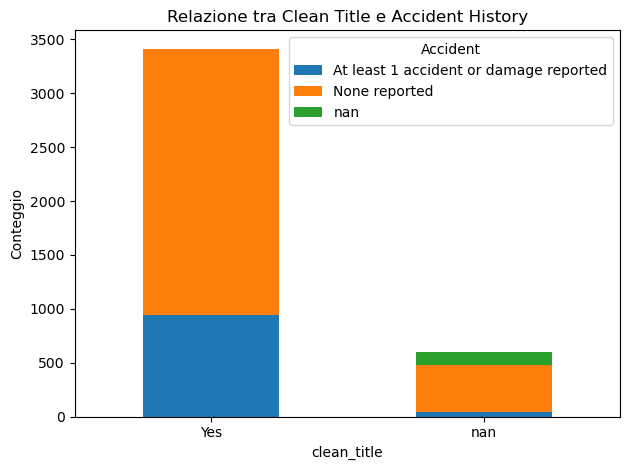

In [286]:
plt.figure(figsize=(10, 6))
# Conta le combinazioni delle due colonne
cross_tab = pd.crosstab(df['clean_title'], df['accident'], dropna=False)
cross_tab.plot(kind='bar', stacked=True)
plt.title('Relazione tra Clean Title e Accident History')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.legend(title='Accident')
plt.tight_layout()
plt.show()

La maggior parte dei veicoli ha un titolo pulito ("Yes"), circa 3500 in totale
Tra i veicoli con titolo pulito:

* Circa 1000 hanno almeno un incidente segnalato (la parte blu)
* Circa 2500 non hanno incidenti segnalati (la parte arancione)

Una quantità molto minore di veicoli ha informazione mancante sul titolo ("nan"), circa 600 in totale
Tra questi veicoli senza informazione sul titolo:

* La maggior parte non ha incidenti segnalati (arancione)
* Una piccola parte ha dati mancanti anche sugli incidenti (verde)

Il grafico suggerisce che i veicoli con titolo pulito sono molto più numerosi e che, indipendentemente dallo stato del titolo, la maggioranza dei veicoli non ha incidenti segnalati.

## Matrice di correlazione per variabili numeriche


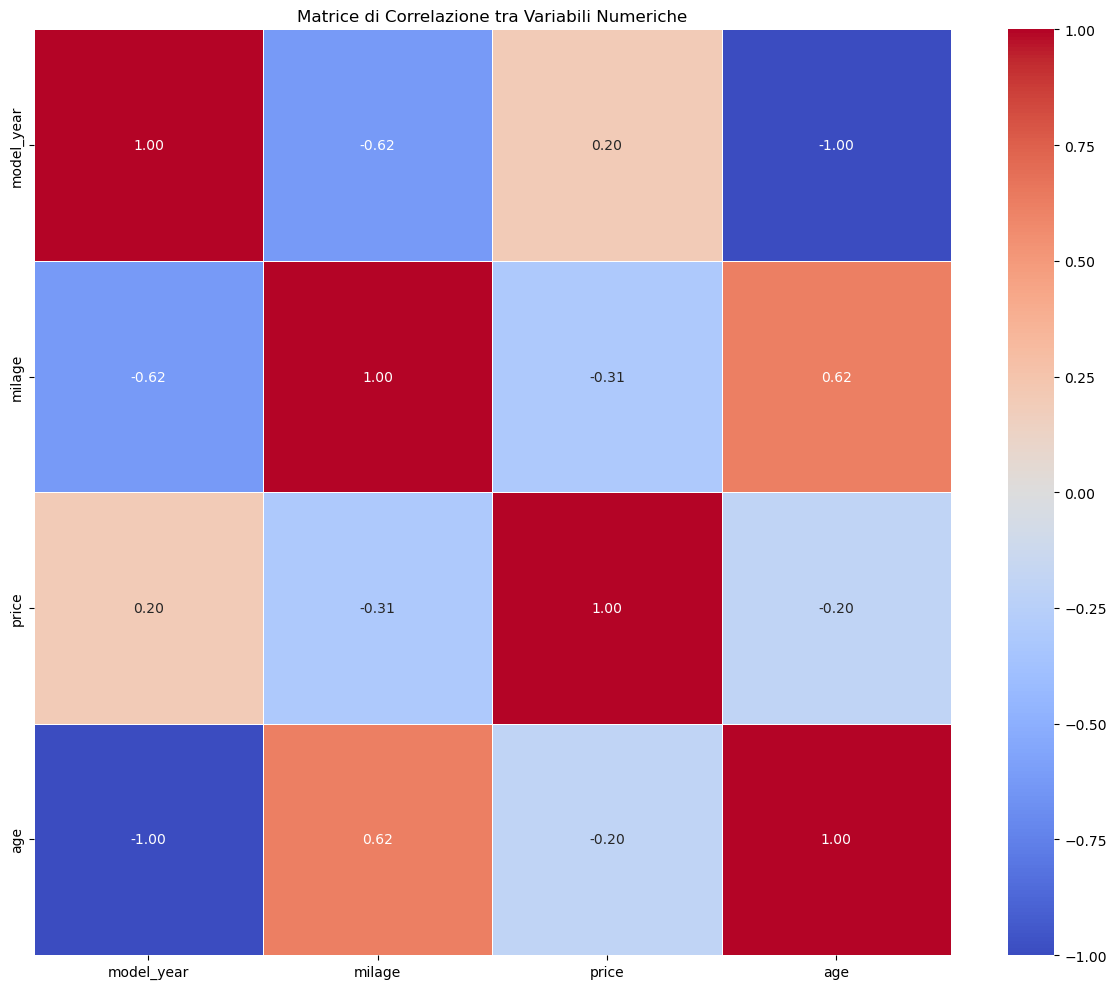

In [287]:
# Seleziona le colonne numeriche
numeric_df = df.select_dtypes(include=[np.number])

# Esclude price_log se presente
if 'price_log' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['price_log'])

# Crea la matrice di correlazione
plt.figure(figsize=(12, 10))
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice di Correlazione tra Variabili Numeriche')
plt.tight_layout()
plt.show()

## Distribuzione dei prezzi

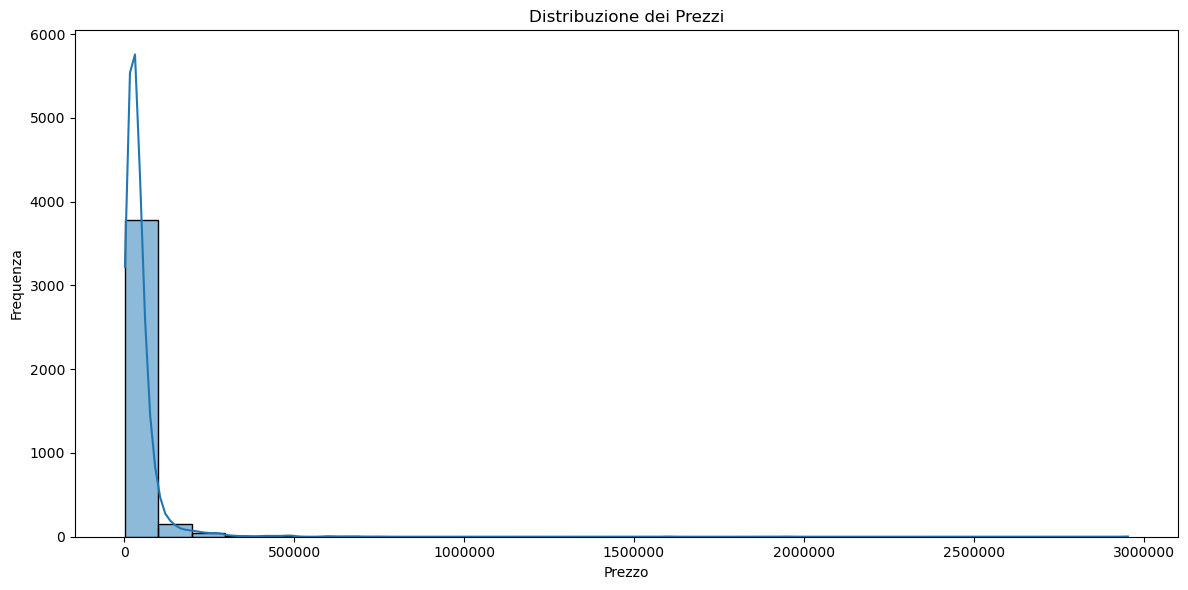

In [288]:

plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribuzione dei Prezzi')
plt.xlabel('Prezzo')
plt.ylabel('Frequenza')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

# 🚨 Distribuzione prezzi mostra una forte asimmetria positiva
può influenzare negativamente i modelli predittivi.
Posso applicare una trasformazione logaritmica per renderla più vicina a una distribuzione normale.
`np.log1p(price)` in seguito se decido di usarla in fase di addestramento del mondello, per le previsioni devo riportarle indietro con `np.expm1()`

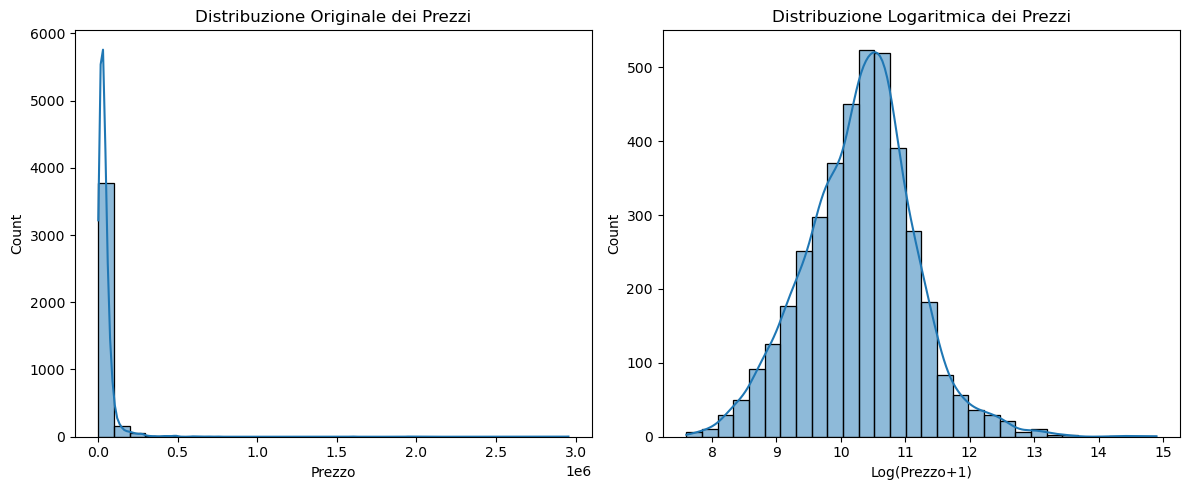

In [289]:
# A. Trasformazione logaritmica
df['price_log'] = np.log1p(df['price'])  # log(1+x) per gestire eventuali zeri

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribuzione Originale dei Prezzi')
plt.xlabel('Prezzo')

plt.subplot(1, 2, 2)
sns.histplot(df['price_log'], bins=30, kde=True)
plt.title('Distribuzione Logaritmica dei Prezzi')
plt.xlabel('Log(Prezzo+1)')

plt.tight_layout()
plt.show()

# I colori hanno peso?

### Colori esterni

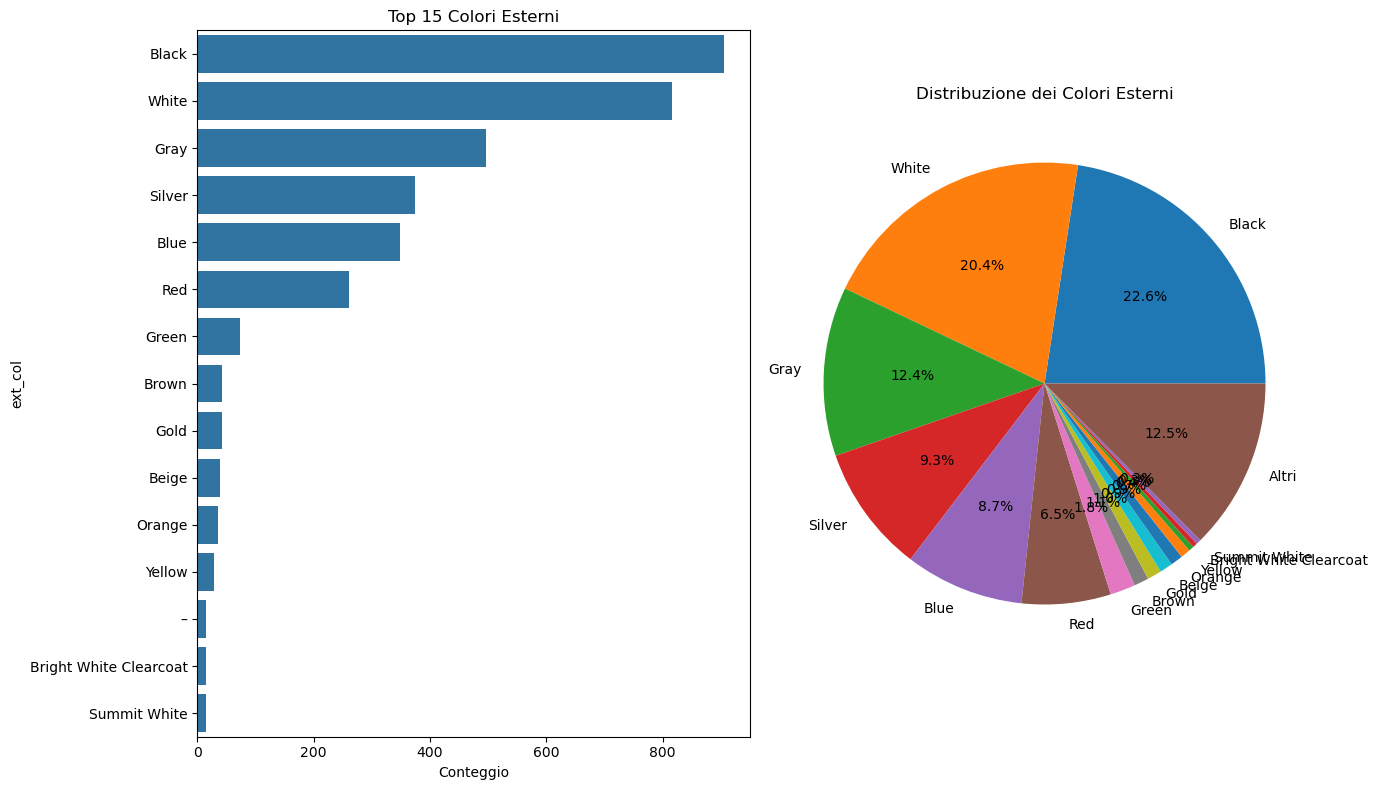

In [290]:
plt.figure(figsize=(14, 8))
color_counts = df['ext_col'].value_counts()
# Limitiamo ai top 15 colori se ce ne sono molti
if len(color_counts) > 15:
    plt.subplot(1, 2, 1)
    top_colors = color_counts.head(15)
    sns.barplot(x=top_colors.values, y=top_colors.index)
    plt.title('Top 15 Colori Esterni')
    plt.xlabel('Conteggio')
    
    plt.subplot(1, 2, 2)
    other_count = color_counts[15:].sum()
    combined = pd.Series(list(top_colors) + [other_count], 
                        index=list(top_colors.index) + ['Altri'])
    plt.pie(combined, labels=combined.index, autopct='%1.1f%%')
    plt.title('Distribuzione dei Colori Esterni')
else:
    sns.barplot(x=color_counts.values, y=color_counts.index)
    plt.title('Distribuzione dei Colori Esterni')
    plt.xlabel('Conteggio')

plt.tight_layout()
plt.show()

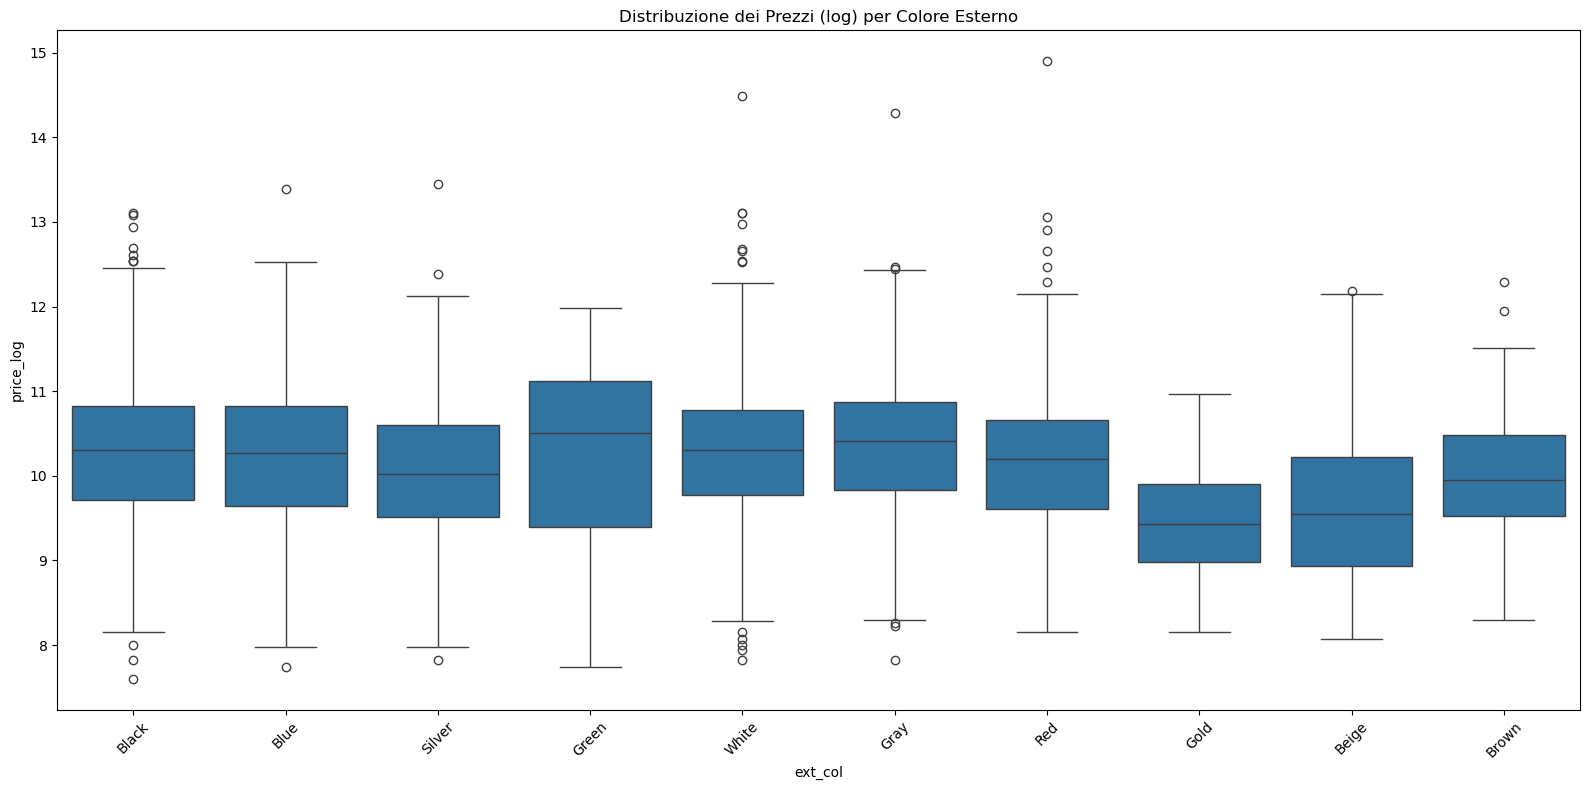

In [291]:
# 3. Relazione tra colori esterni e prezzo (boxplot)
plt.figure(figsize=(16, 8))
# Limitiamo ai top 10 colori più comuni per leggibilità
top_ext_colors = df['ext_col'].value_counts().head(10).index
df_top_colors = df[df['ext_col'].isin(top_ext_colors)]

sns.boxplot(x='ext_col', y='price_log', data=df_top_colors)
plt.title('Distribuzione dei Prezzi (log) per Colore Esterno')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La maggior parte dei colori ha una mediana di prezzo simile, intorno al valore 10-11 sulla scala logaritmica
* Beige e Orange sembrano avere prezzi mediani leggermente più bassi
* Alcuni colori come White, Black e Red mostrano outlier verso l'alto, indicando veicoli particolarmente costosi con questi colori
* La variabilità dei prezzi (altezza delle scatole) differisce tra i colori

### Colori interni

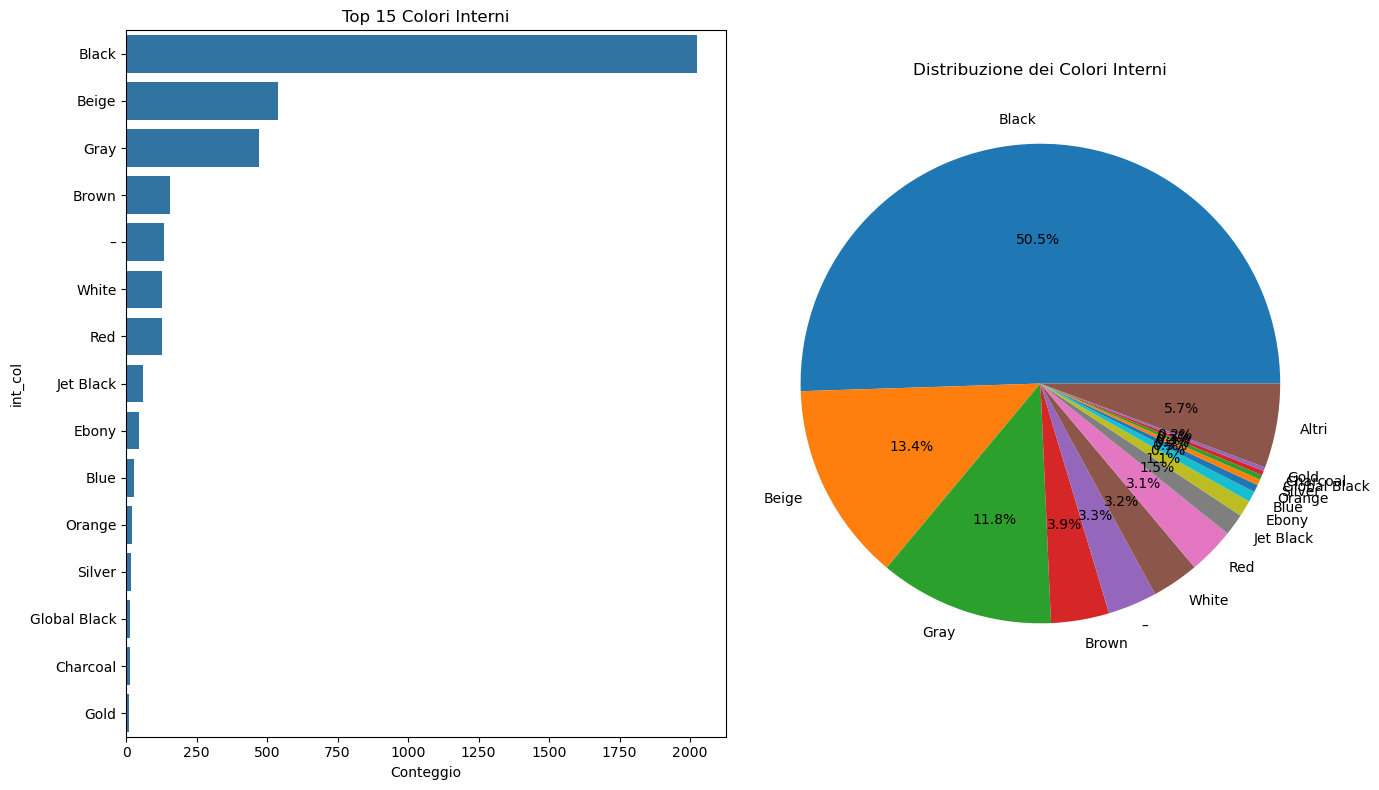

In [292]:
plt.figure(figsize=(14, 8))
int_color_counts = df['int_col'].value_counts()
# Limitiamo ai top 15 colori se ce ne sono molti
if len(int_color_counts) > 15:
    plt.subplot(1, 2, 1)
    top_int_colors = int_color_counts.head(15)
    sns.barplot(x=top_int_colors.values, y=top_int_colors.index)
    plt.title('Top 15 Colori Interni')
    plt.xlabel('Conteggio')
    
    plt.subplot(1, 2, 2)
    other_int_count = int_color_counts[15:].sum()
    combined_int = pd.Series(list(top_int_colors) + [other_int_count], 
                            index=list(top_int_colors.index) + ['Altri'])
    plt.pie(combined_int, labels=combined_int.index, autopct='%1.1f%%')
    plt.title('Distribuzione dei Colori Interni')
else:
    sns.barplot(x=int_color_counts.values, y=int_color_counts.index)
    plt.title('Distribuzione dei Colori Interni')
    plt.xlabel('Conteggio')

plt.tight_layout()
plt.show()

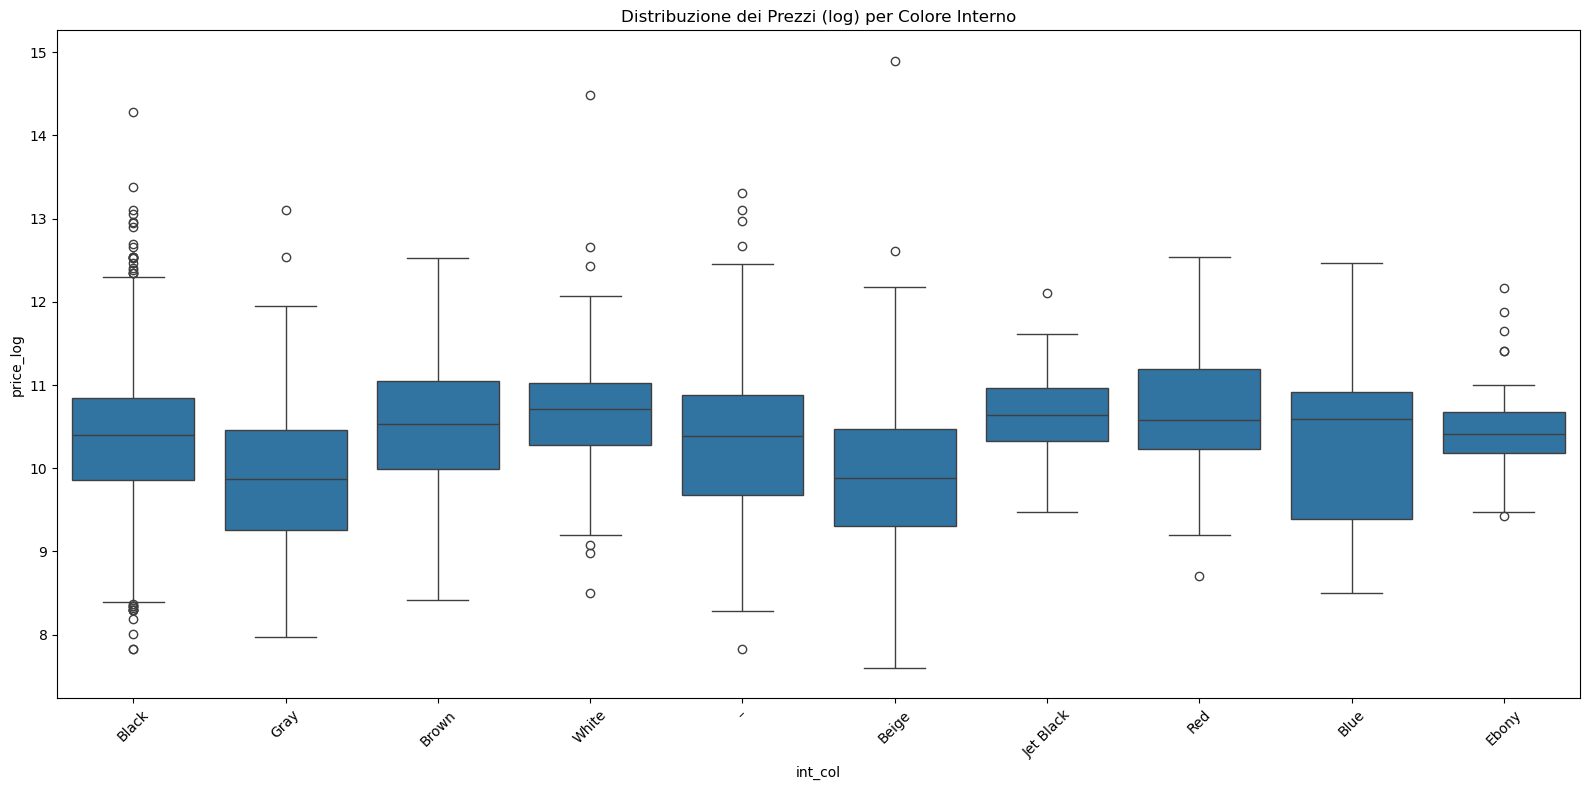

In [293]:
# 4. Relazione tra colori interni e prezzo (boxplot)
plt.figure(figsize=(16, 8))
# Limitiamo ai top 10 colori più comuni per leggibilità
top_int_colors = df['int_col'].value_counts().head(10).index
df_top_int_colors = df[df['int_col'].isin(top_int_colors)]

sns.boxplot(x='int_col', y='price_log', data=df_top_int_colors)
plt.title('Distribuzione dei Prezzi (log) per Colore Interno')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dal grafico possiamo osservare:

* I box plot mostrano variazioni nel prezzo mediano tra i diversi colori interni
* Alcuni colori (come Grey e Graphite) sembrano avere una mediana di prezzo più bassa
* Altri colori (come Red e Blue) presentano mediane più alte
* Vari colori mostrano outlier (cerchi isolati), indicando veicoli con prezzi significativamente più alti o più bassi rispetto alla distribuzione generale

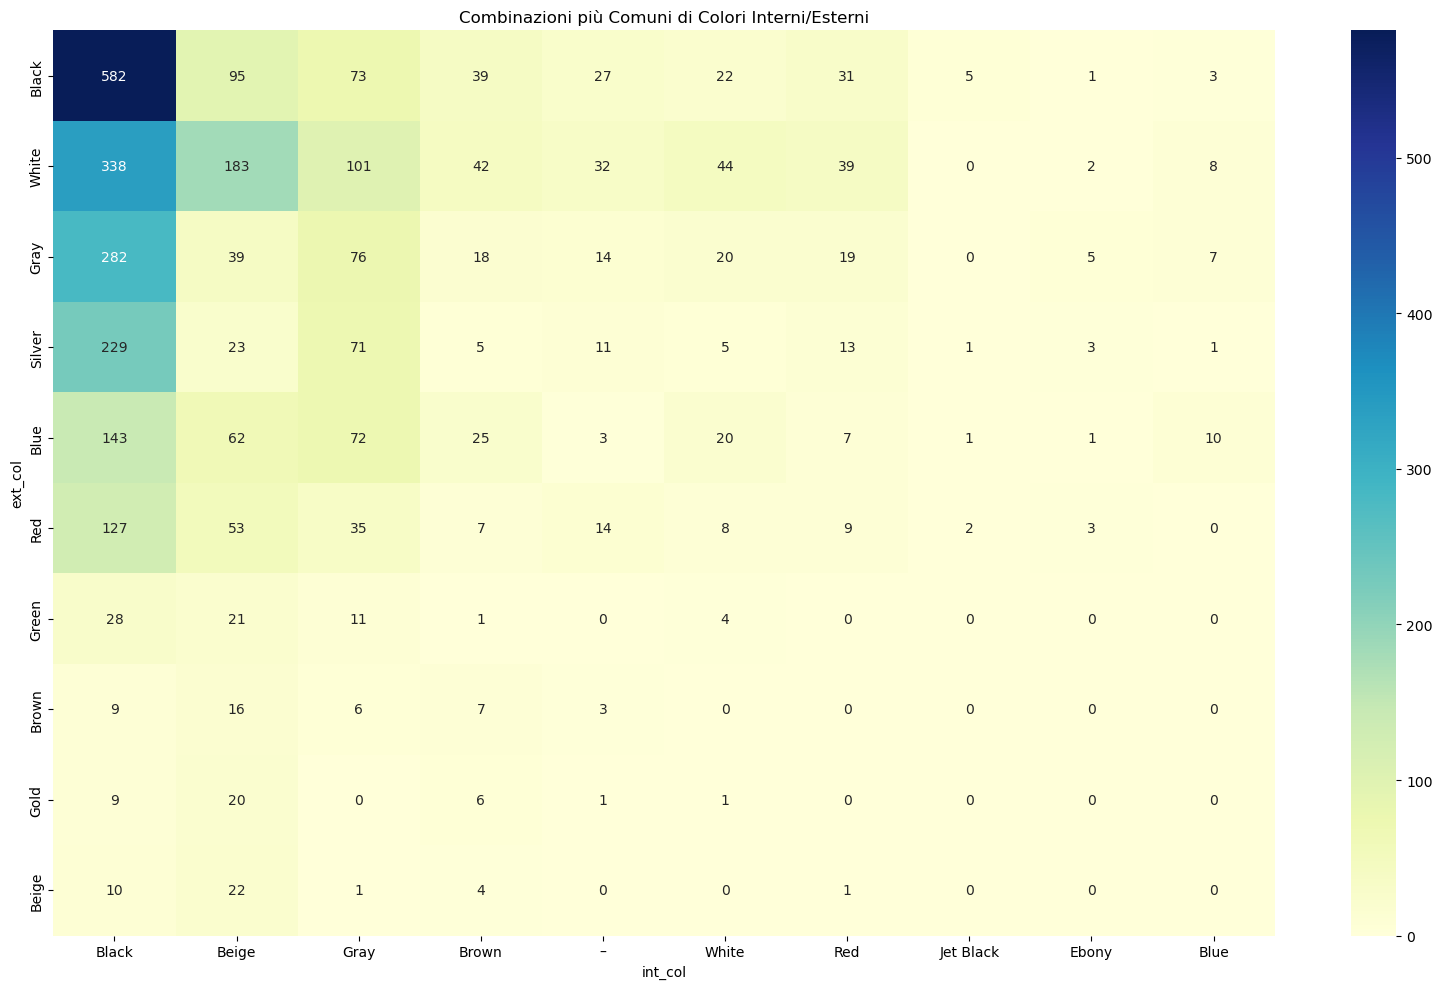

In [294]:
# 5. Heatmap delle combinazioni colore interno/esterno più comuni
plt.figure(figsize=(16, 10))
color_combo = pd.crosstab(df['ext_col'], df['int_col'])
# Limitiamo ai top 10 colori interni ed esterni per leggibilità
top_ext = df['ext_col'].value_counts().head(10).index
top_int = df['int_col'].value_counts().head(10).index
color_combo_filtered = color_combo.loc[top_ext, top_int]

sns.heatmap(color_combo_filtered, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Combinazioni più Comuni di Colori Interni/Esterni')
plt.tight_layout()
plt.show()

Le osservazioni principali sono:

**La combinazione più comune è Black (esterno) con Black (interno), con 582 veicoli**
Altre combinazioni frequenti includono:

* Black (esterno) con White (interno): 338 veicoli
* Black (esterno) con Gray (interno): 282 veicoli
* Black (esterno) con Silver (interno): 229 veicoli



**Le combinazioni con il colore esterno Black sono generalmente le più numerose per quasi tutti i colori interni, suggerendo che il nero è il colore esterno predominante indipendentemente dal colore interno.**

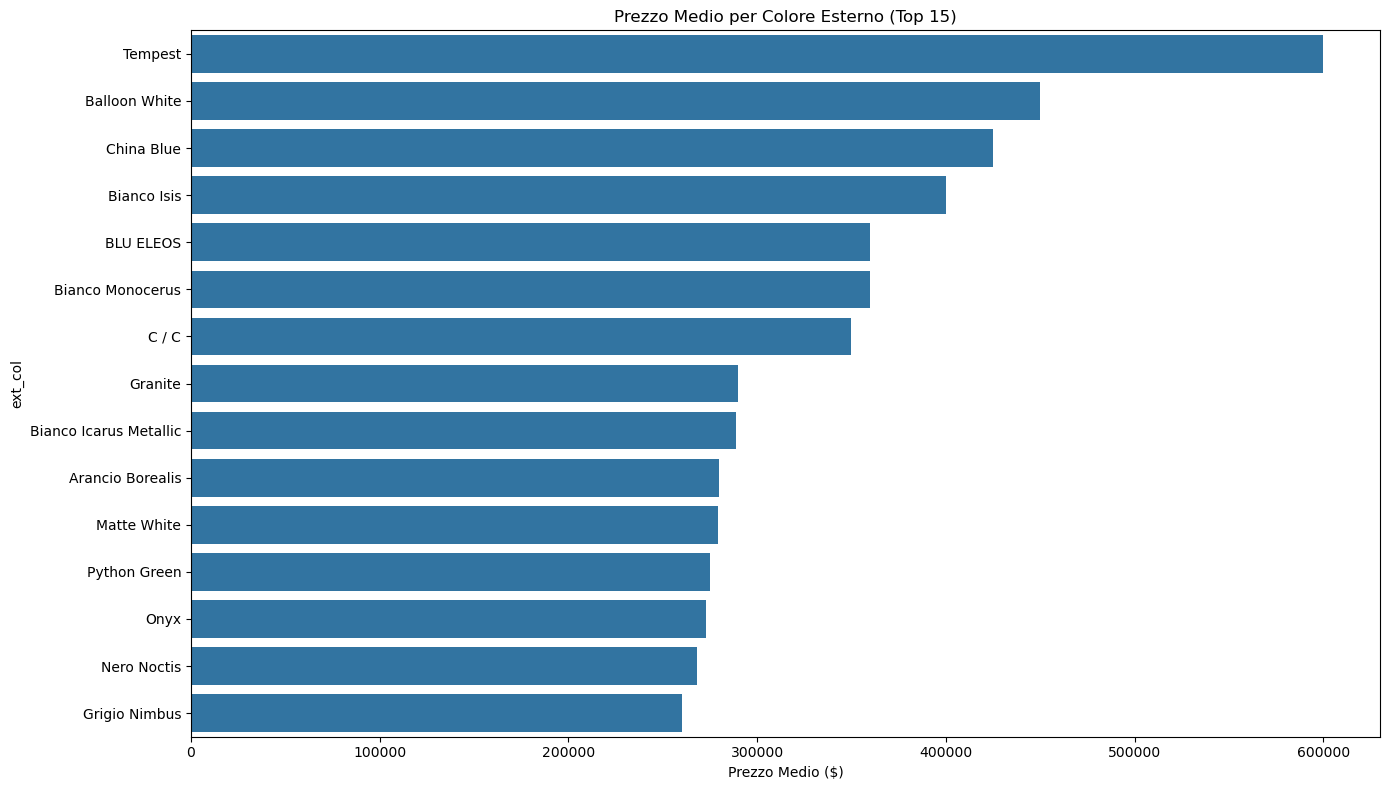

In [295]:
# 6. Prezzo medio per colore esterno
plt.figure(figsize=(14, 8))
color_price = df.groupby('ext_col')['price'].mean().sort_values(ascending=False)
# Limitiamo ai top 15 colori
top_color_price = color_price.head(15)
sns.barplot(x=top_color_price.values, y=top_color_price.index)
plt.title('Prezzo Medio per Colore Esterno (Top 15)')
plt.xlabel('Prezzo Medio ($)')
plt.tight_layout()
plt.show()

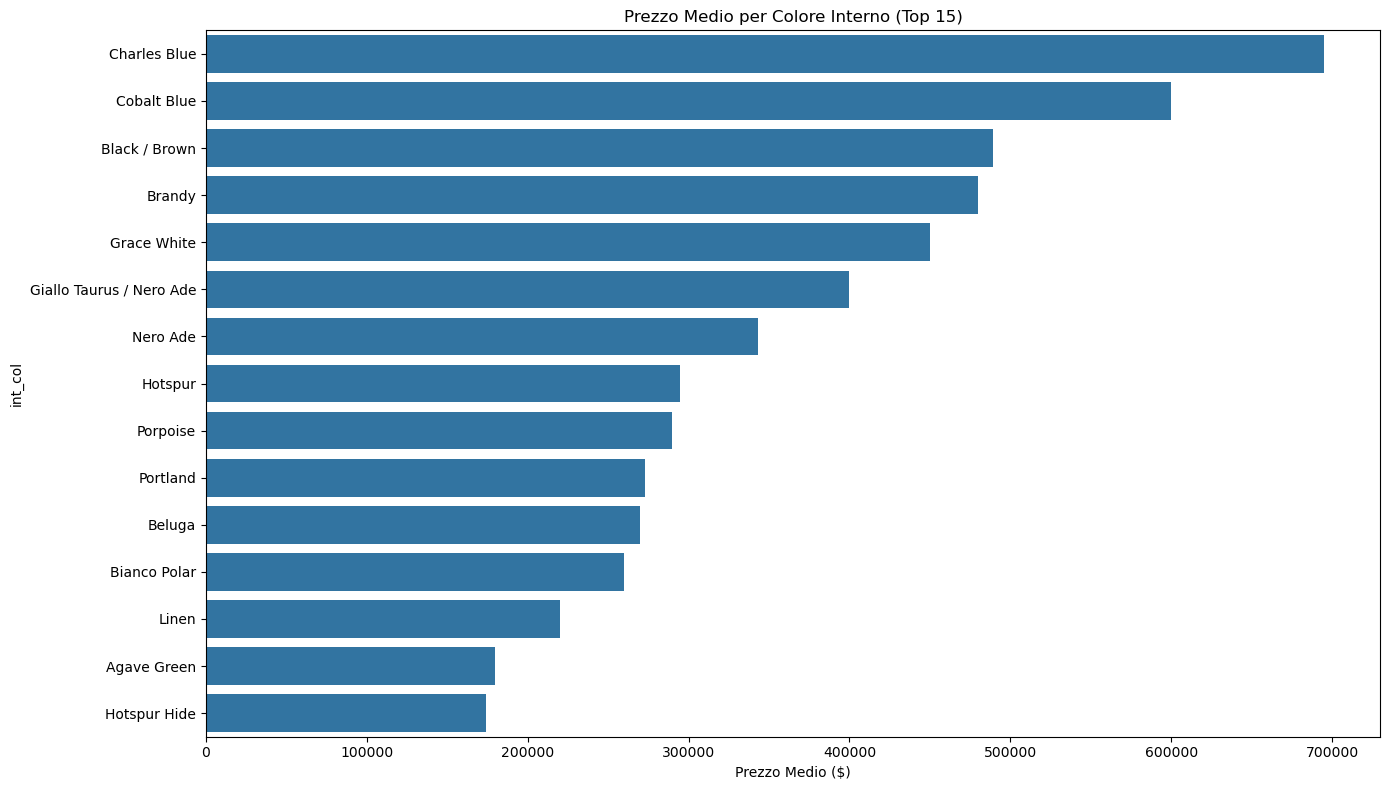

In [296]:
# 7. Prezzo medio per colore interno
plt.figure(figsize=(14, 8))
int_color_price = df.groupby('int_col')['price'].mean().sort_values(ascending=False)
# Limitiamo ai top 15 colori
top_int_color_price = int_color_price.head(15)
sns.barplot(x=top_int_color_price.values, y=top_int_color_price.index)
plt.title('Prezzo Medio per Colore Interno (Top 15)')
plt.xlabel('Prezzo Medio ($)')
plt.tight_layout()
plt.show()

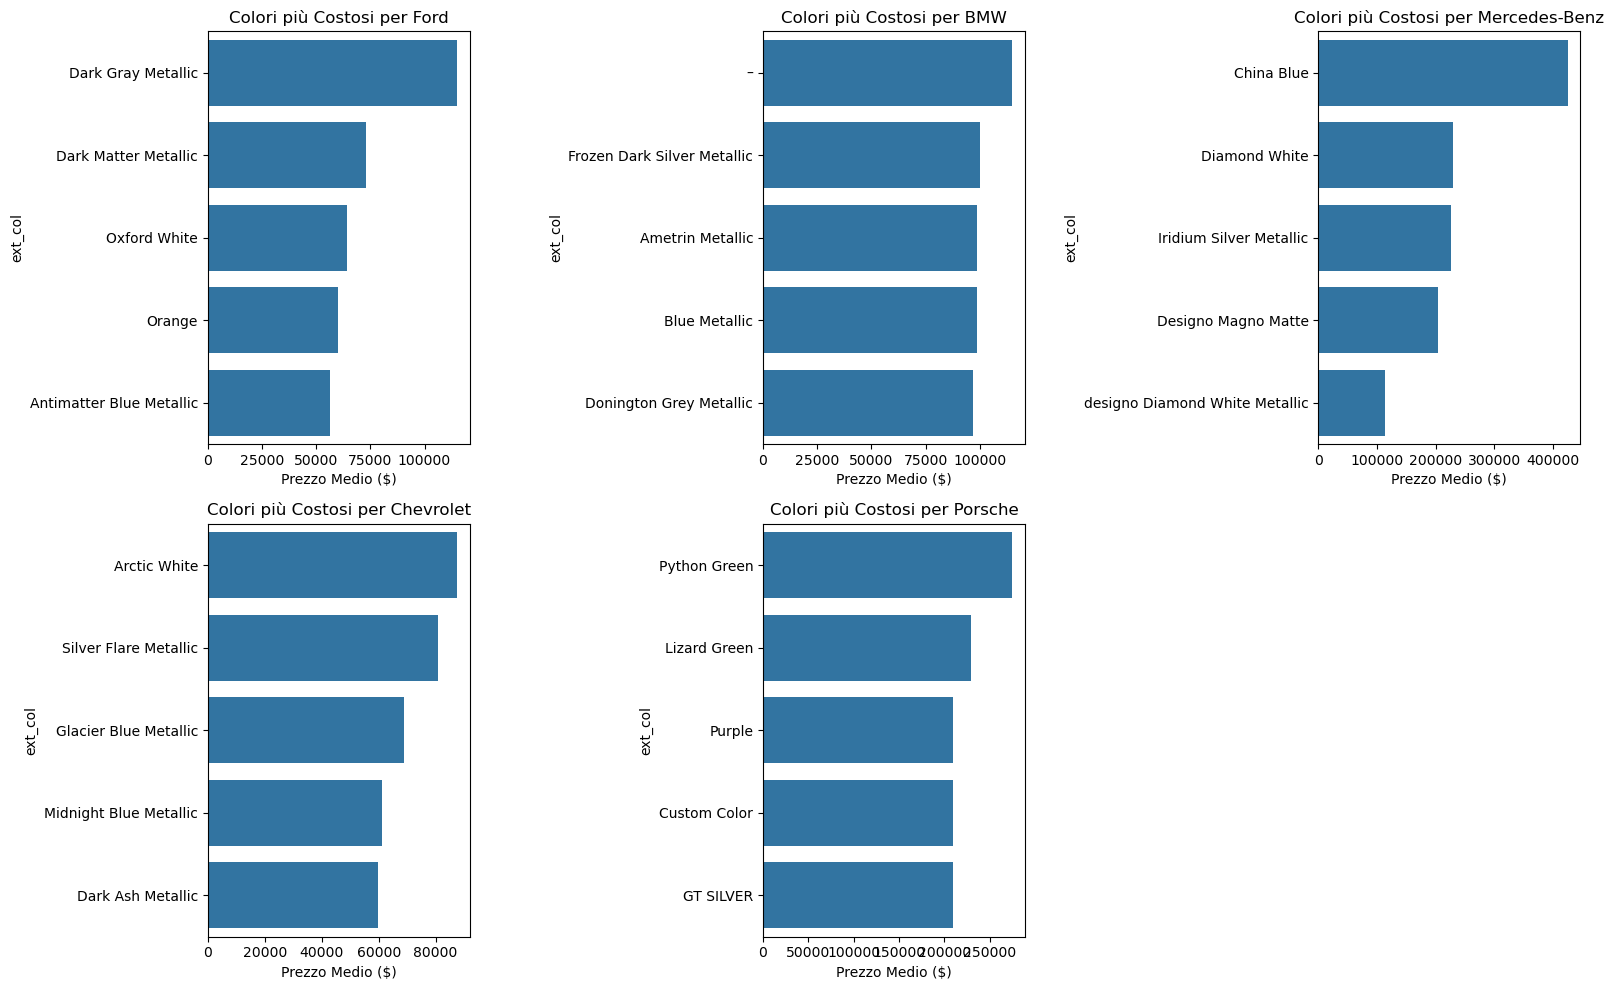

In [297]:
# 8. Analisi delle combinazioni colore-marca più costose
plt.figure(figsize=(16, 10))
# Consideriamo solo i top brand
top_brands = df['brand'].value_counts().head(5).index
df_top_brands = df[df['brand'].isin(top_brands)]

# Creiamo un grafico per ogni top brand
for i, brand in enumerate(top_brands, 1):
    plt.subplot(2, 3, i)
    brand_data = df_top_brands[df_top_brands['brand'] == brand]
    brand_color_price = brand_data.groupby('ext_col')['price'].mean().sort_values(ascending=False).head(5)
    
    if not brand_color_price.empty:
        sns.barplot(x=brand_color_price.values, y=brand_color_price.index)
        plt.title(f'Colori più Costosi per {brand}')
        plt.xlabel('Prezzo Medio ($)')
    
plt.tight_layout()
plt.show()

Per ogni marca, vengono mostrati i 5 colori esterni che hanno il prezzo medio più alto:

* Per Ford: Dark Gray Metallic è il colore più costoso, seguito da Dark Matter Metallic, Oxford White, Orange e Antimatter Blue Metallic
* Per BMW: Un colore non completamente visibile è il più costoso, seguito da Frozen Dark Silver Metallic, Aventurin Metallic, Blue Metallic e Dravit Grey Metallic
* Per Mercedes-Benz: China Blue è il più costoso, seguito da Diamond White, Yttrium Silver Metallic, Designo Magno Matte e Designo Diamond White Metallic
* Per Chevrolet: Arctic White è il più costoso, seguito da Silver Flare Metallic, Glacier Blue Metallic, Midnight Blue Metallic e Dark Ash Metallic
* Per Porsche: Python Green è il più costoso, seguito da Lizard Green, Marjan, Custom Color e GT Silver

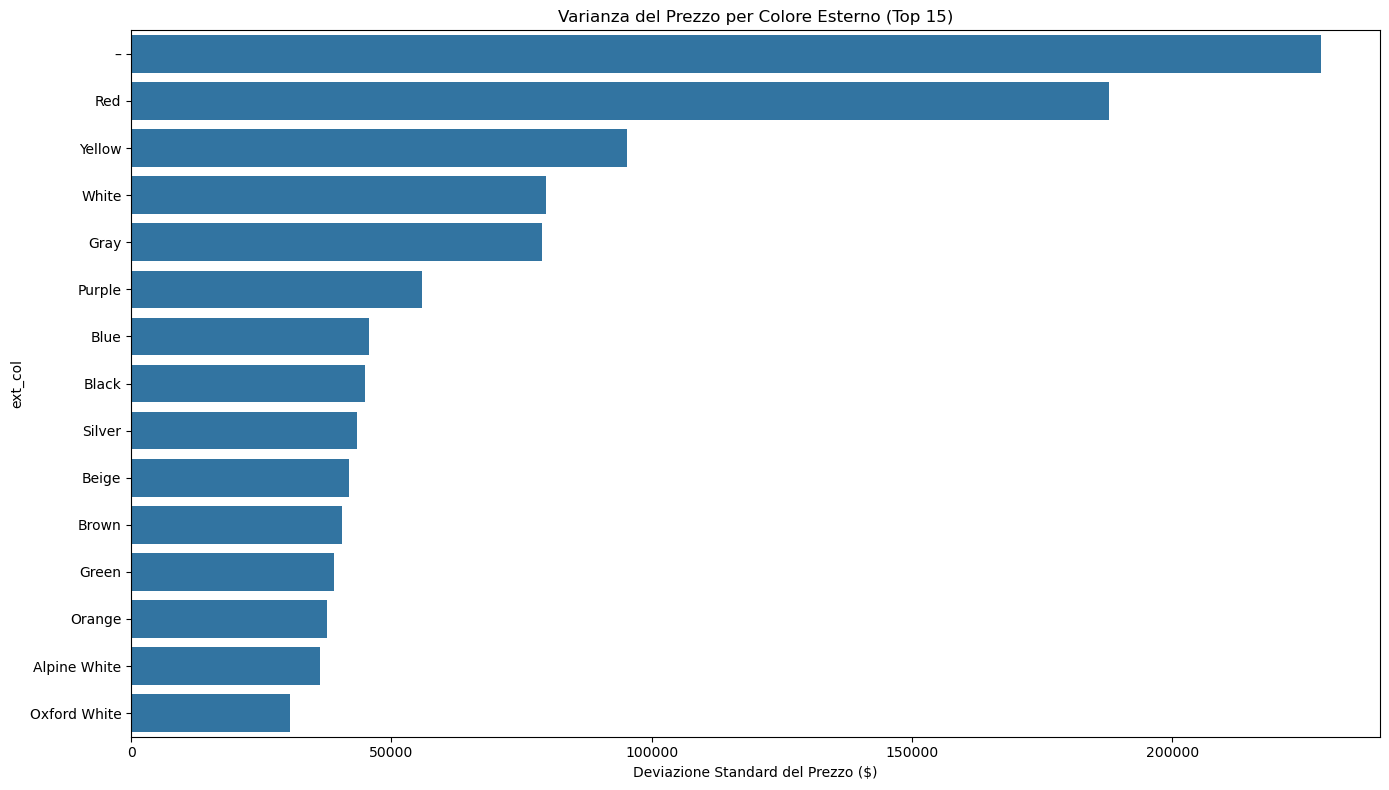

In [298]:
# 9. Analisi della varianza di prezzo per colore
plt.figure(figsize=(14, 8))
# Calcoliamo la deviazione standard del prezzo per ogni colore esterno
color_price_std = df.groupby('ext_col')['price'].std().sort_values(ascending=False)
# Filtriamo per colori con almeno 5 esempi
color_counts = df['ext_col'].value_counts()
valid_colors = color_counts[color_counts >= 5].index
color_price_std_filtered = color_price_std[color_price_std.index.isin(valid_colors)]

# Top 15 colori con maggiore varianza
top_color_std = color_price_std_filtered.head(15)
sns.barplot(x=top_color_std.values, y=top_color_std.index)
plt.title('Varianza del Prezzo per Colore Esterno (Top 15)')
plt.xlabel('Deviazione Standard del Prezzo ($)')
plt.tight_layout()
plt.show()



Questo grafico a barre orizzontali mostra la deviazione standard del prezzo per i 15 colori esterni più comuni. I colori con maggiore variabilità nei prezzi sono:

* Red (rosso) con la barra più lunga, indicando la maggiore variabilità di prezzo (ha anche la macchina più costosa in assoluto)
* Black (nero), con la seconda maggiore variabilità
* Yellow (giallo)
* White (bianco)
* Gray (grigio)

I colori con minore variabilità nei prezzi includono Oxford White e Alpine White in fondo al grafico.

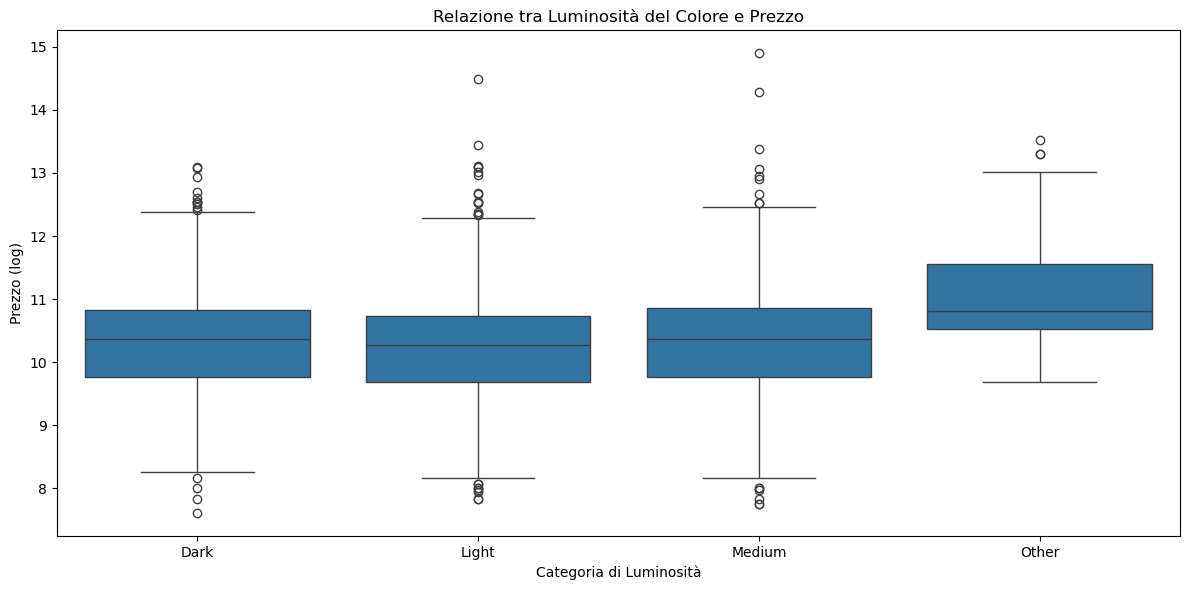

In [299]:
# 10. Correlazione tra luminosità del colore e prezzo
# Classifichiamo i colori in gruppi di luminosità
def categorize_color_brightness(color):
    light_colors = ['White', 'Silver', 'Beige', 'Gold', 'Yellow', 'Light']
    dark_colors = ['Black', 'Navy', 'Brown', 'Dark']
    medium_colors = ['Red', 'Blue', 'Green', 'Orange', 'Purple', 'Gray']
    
    color = str(color).lower()
    
    if any(light in color.lower() for light in map(str.lower, light_colors)):
        return 'Light'
    elif any(dark in color.lower() for dark in map(str.lower, dark_colors)):
        return 'Dark'
    elif any(medium in color.lower() for medium in map(str.lower, medium_colors)):
        return 'Medium'
    else:
        return 'Other'

# Aggiungiamo la categoria di luminosità
df['ext_color_brightness'] = df['ext_col'].apply(categorize_color_brightness)

# Visualizziamo la relazione tra luminosità e prezzo
plt.figure(figsize=(12, 6))
sns.boxplot(x='ext_color_brightness', y='price_log', data=df)
plt.title('Relazione tra Luminosità del Colore e Prezzo')
plt.xlabel('Categoria di Luminosità')
plt.ylabel('Prezzo (log)')
plt.tight_layout()
plt.show()

Si può osservare che la categoria "Other" ha una mediana di prezzo più alta rispetto alle altre categorie di luminosità, mentre i colori Dark, Light e Medium hanno distribuzioni di prezzo simili tra loro.

Questi grafici suggeriscono che **i colori rossi e neri non solo sono popolari ma hanno anche una grande variabilità di prezzo, probabilmente perché sono disponibili su veicoli in diverse fasce di prezzo**, dalle economiche alle premium. Inoltre, sembra esserci una **correlazione tra la luminosità del colore e il prezzo, con colori nella categoria "Other" (probabilmente colori speciali o personalizzati) che tendono ad avere prezzi più alti.**

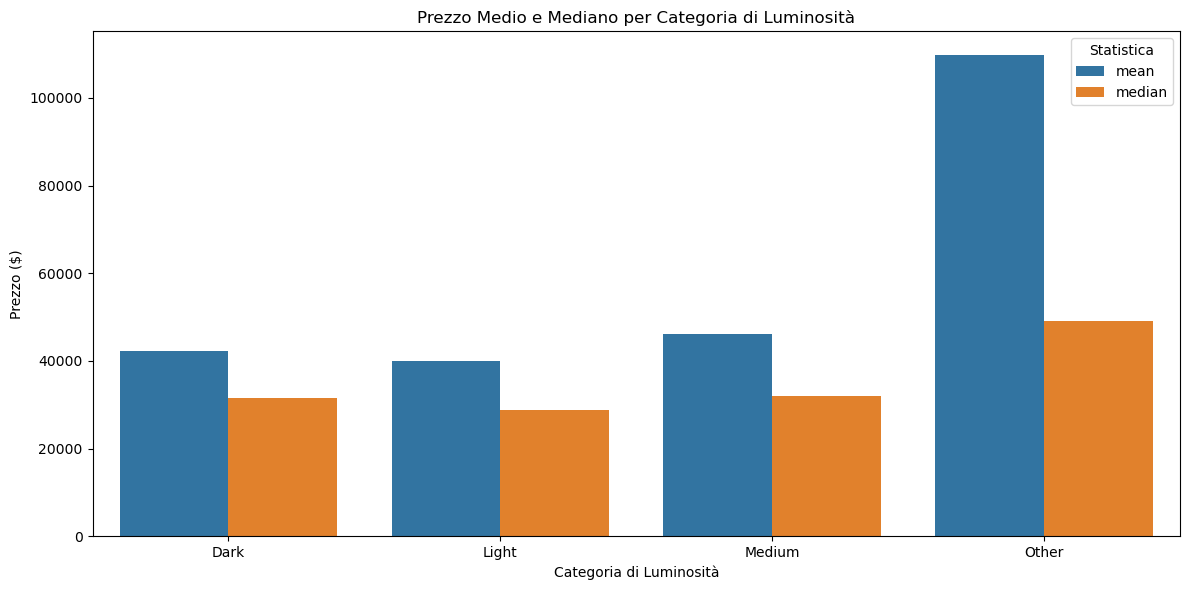

In [300]:
# 11. Media e mediana del prezzo per categoria di luminosità
plt.figure(figsize=(12, 6))
brightness_stats = df.groupby('ext_color_brightness')['price'].agg(['mean', 'median']).reset_index()
brightness_stats = brightness_stats.melt(id_vars='ext_color_brightness', 
                                      value_vars=['mean', 'median'],
                                      var_name='Statistica', value_name='Prezzo')

sns.barplot(x='ext_color_brightness', y='Prezzo', hue='Statistica', data=brightness_stats)
plt.title('Prezzo Medio e Mediano per Categoria di Luminosità')
plt.xlabel('Categoria di Luminosità')
plt.ylabel('Prezzo ($)')
plt.tight_layout()
plt.show()

La differenza notevole tra media e mediana nella categoria "Other" suggerisce la presenza di alcuni veicoli con prezzi molto elevati che influenzano la media. Forse come detto sopra versioni custom per super ricchi 🤑

## Analisi dei brand più comuni


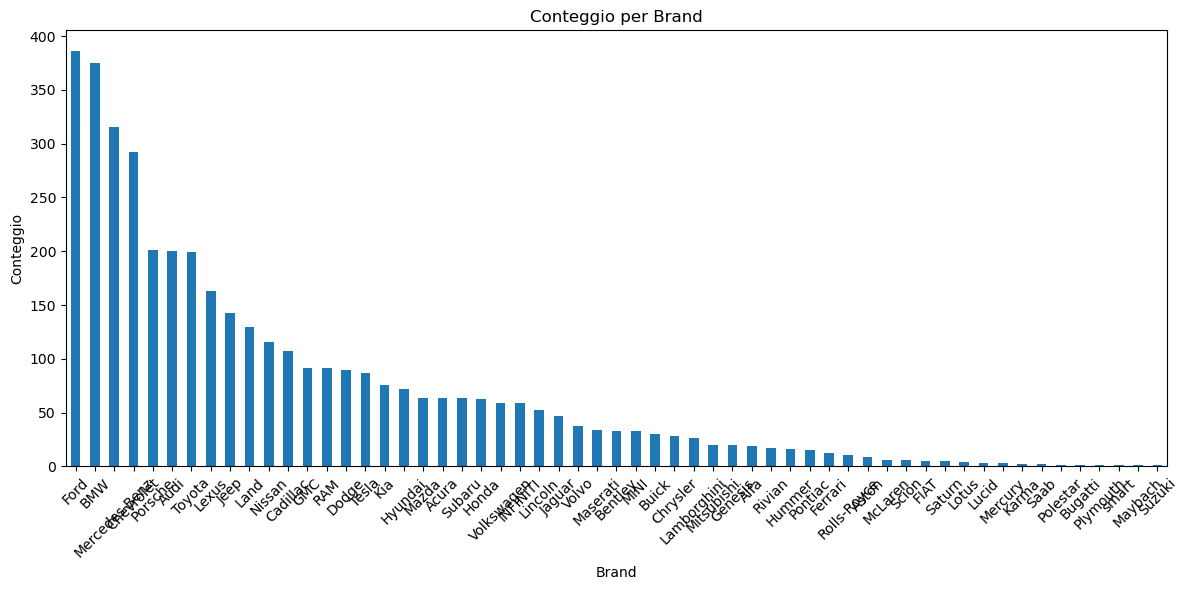

In [301]:
plt.figure(figsize=(12, 6))
df['brand'].value_counts().plot(kind='bar')
plt.title('Conteggio per Brand')
plt.xlabel('Brand')
plt.ylabel('Conteggio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Relazione tra brand e prezzo

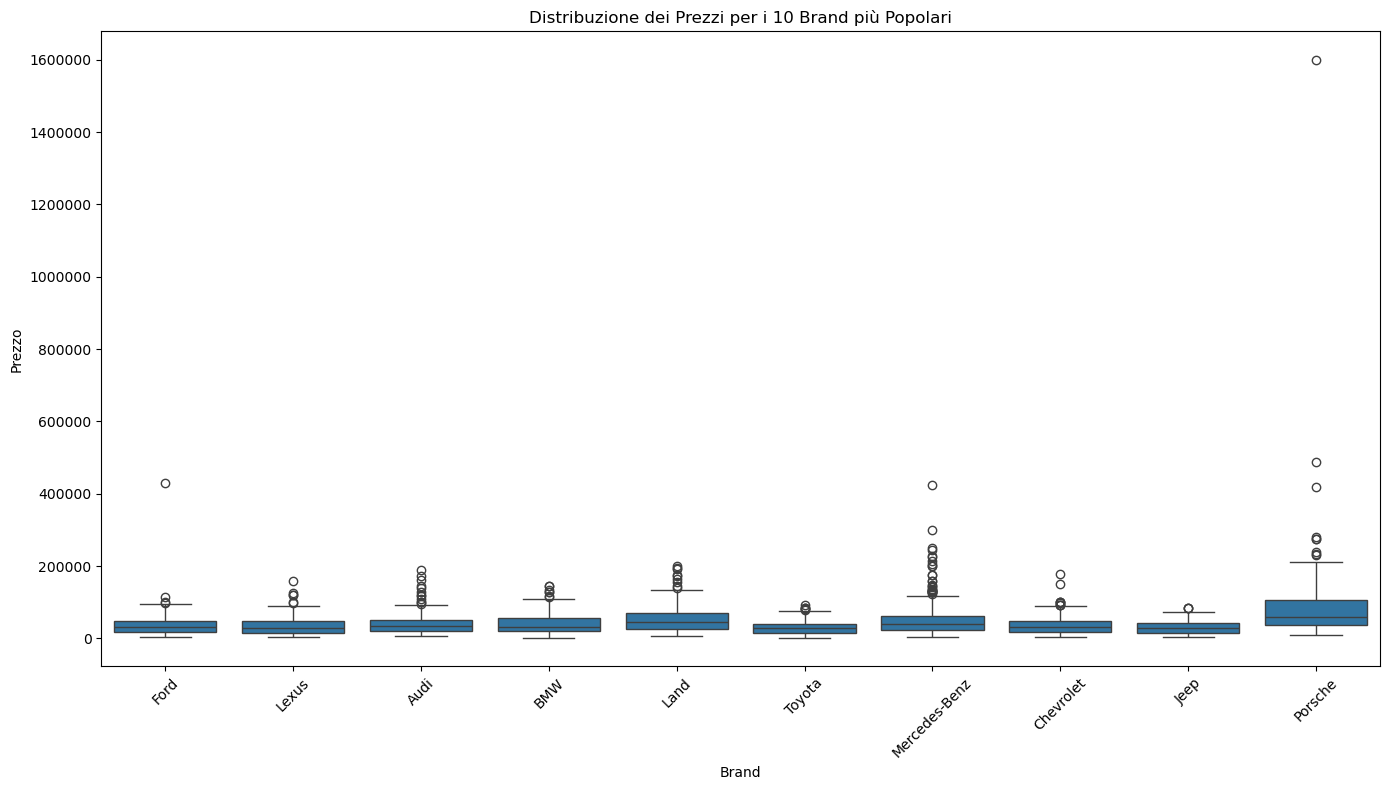

In [302]:

# Identifica i primi 10 brand (ad esempio, per numero di prodotti)
top_10_brands = df['brand'].value_counts().nlargest(10).index.tolist()

# Filtra il dataframe per includere solo questi brand
df_top10 = df[df['brand'].isin(top_10_brands)]

# Crea il box plot con i dati filtrati
plt.figure(figsize=(14, 8))
sns.boxplot(x='brand', y='price', data=df_top10)
plt.title('Distribuzione dei Prezzi per i 10 Brand più Popolari')
plt.xlabel('Brand')
plt.ylabel('Prezzo')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

* La maggior parte dei box plot è compressa nella parte inferiore del grafico
* Gli outlier sono molto più evidenti e distanziati dal corpo principale dei dati
* C'è un outlier estremo (probabilmente un'auto di lusso o da collezione) che raggiunge circa 1.600.000 dollari

Con questa scala lineare:

* Porsche mostra più chiaramente valori più alti e diversi outlier significativi
* Mercedes-Benz ha diversi outlier di alto valore
* La maggior parte delle auto di tutti i brand si concentra nella fascia di prezzo più bassa (sotto i 100.000 dollari)
* I box principali (che rappresentano il 50% centrale dei dati) sono tutti compressi nella parte inferiore

la distribuzione dei prezzi è fortemente asimmetrica (skewed) verso destra, con la maggior parte dei valori concentrati in basso e pochi outlier che distorcono la visione complessiva. La scala logaritmica, usata nei grafici precedenti, permette di apprezzare meglio le differenze tra i vari brand nella fascia di prezzi più comune.

## Relazione tra model_year e prezzo


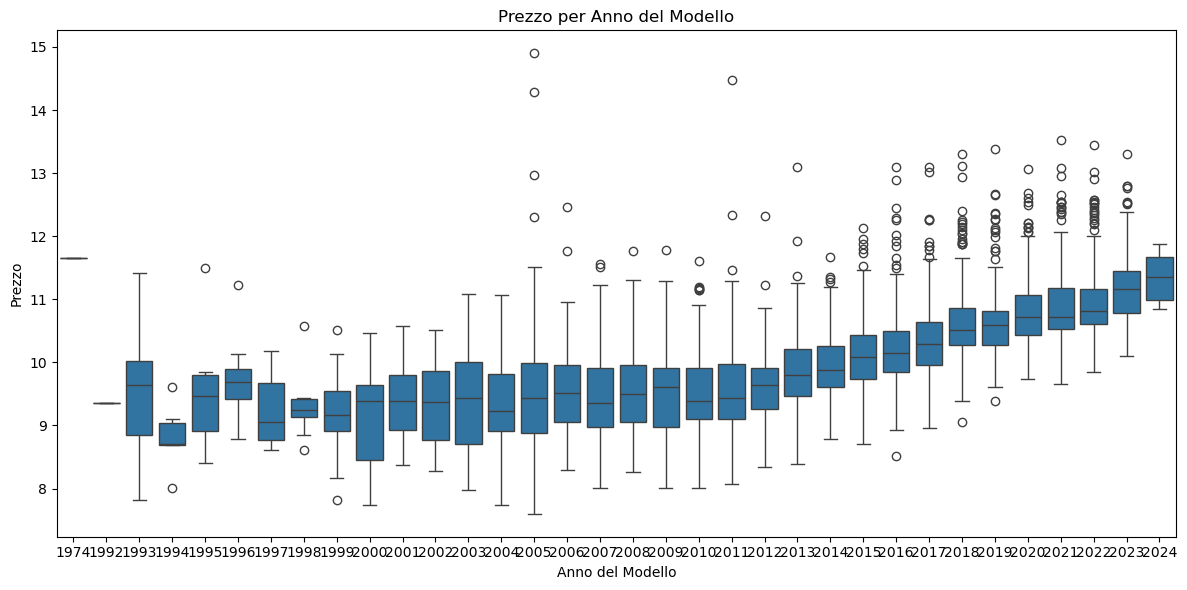

In [303]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='model_year', y='price_log', data=df)
plt.title('Prezzo per Anno del Modello')
plt.xlabel('Anno del Modello')
plt.ylabel('Prezzo')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

C'è una chiara tendenza all'aumento dei prezzi mediani con gli anni più recenti. Le auto più nuove costano generalmente di più delle auto più vecchie.
* La mediana del prezzo (linea orizzontale in ogni box) aumenta progressivamente spostandosi verso destra (anni più recenti).
* Gli anni più recenti (dal 2010 in poi) mostrano box plot mediamente più alti e con maggiori outlier verso l'alto.
* Le auto più vecchie (anni '70-'80) tendono ad avere prezzi più bassi e meno variabilità.
* Si nota una maggiore dispersione dei valori (più outlier) per i modelli degli ultimi 10-15 anni.

Questa visualizzazione **conferma l'intuitivo concetto che, in generale, le auto più recenti tendono ad avere un valore di mercato più elevato rispetto a quelle più datate**, con un trend crescente piuttosto chiaro nel tempo.

# Relazione tra chilometraggio e prezzo

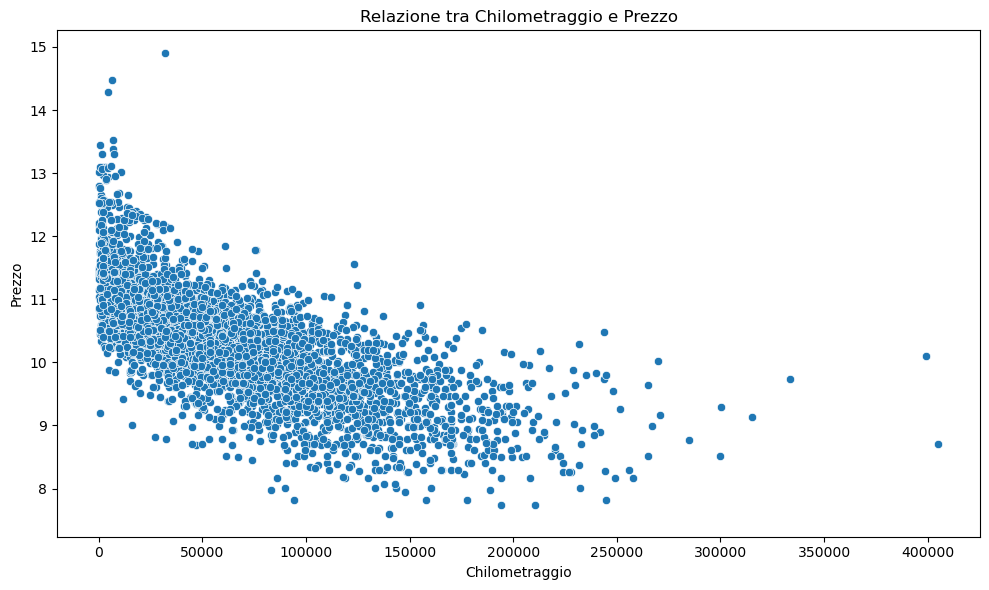

In [304]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='milage', y='price_log', data=df)
plt.title('Relazione tra Chilometraggio e Prezzo')
plt.xlabel('Chilometraggio')
plt.ylabel('Prezzo')
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

C'è una chiara correlazione negativa tra chilometraggio e prezzo: **all'aumentare del chilometraggio, il prezzo tende a diminuire**

* La densità dei punti è maggiore nella zona con chilometraggio basso (0-100.000 km) e prezzi più alti
* La curva di discesa del prezzo è più ripida inizialmente (nei primi 100.000 km) e poi tende a diventare più graduale
Ci sono alcuni outlier interessanti:

* Auto con chilometraggi molto alti (>300.000 km) ma prezzi relativamente sostenuti
* Auto con chilometraggi molto bassi ma prezzi relativamente variabili (alcuni molto alti, altri più bassi)


**La distribuzione dei punti forma una "nuvola" che si assottiglia verso destra, indicando che le auto con alto chilometraggio sono meno comuni nel dataset**

Questo grafico conferma l'intuitiva **relazione inversa tra chilometraggio e valore di un'auto**: più un'auto ha percorso chilometri, più il suo valore di mercato tende a diminuire, con un effetto particolarmente marcato nei primi 100.000 km di utilizzo.

# 🚨 Prezzi outlier
Tutti i grafici mostrano 3 grossi outlier, con prezzi sopra i 1,5M


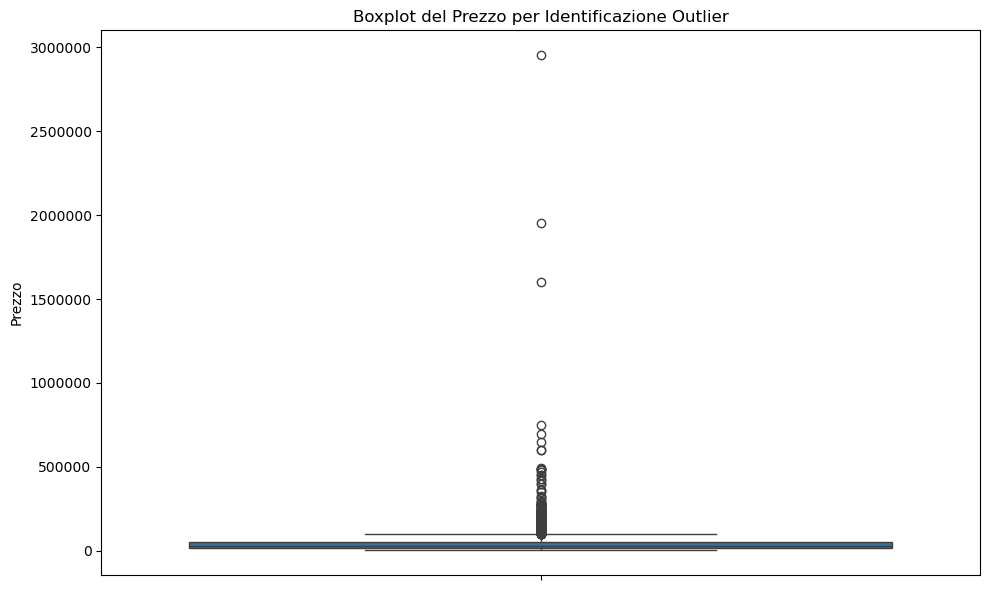

In [305]:
# Verifica degli outlier con boxplot per il prezzo
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['price'])
plt.title('Boxplot del Prezzo per Identificazione Outlier')
plt.ylabel('Prezzo')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [306]:
# Z-Score per identificare outlier nel prezzo (senza normalizzazione)
z_scores = stats.zscore(df['price'])
outliers = (abs(z_scores) > 3)
print(f"\nNumero di outlier nel prezzo (z-score > 3): {outliers.sum()}")


Numero di outlier nel prezzo (z-score > 3): 31


# CERCO DI INTENTIFICARE gli outlier

In [307]:
# Visualizziamo gli outlier
outlier_data = df[outliers]
print("\nDettagli degli outlier:")
print(outlier_data[['brand', 'model', 'price', 'model_year', 'ext_col']].sort_values(by='price', ascending=False))


Dettagli degli outlier:
              brand                            model      price  model_year  \
693        Maserati                Quattroporte Base  2954083.0        2005   
229         Bugatti          Veyron 16.4 Grand Sport  1950995.0        2011   
3046        Porsche                  Carrera GT Base  1599000.0        2005   
1356    Lamborghini               Aventador SVJ Base   749950.0        2021   
624     Rolls-Royce                         Cullinan   695000.0        2022   
979     Lamborghini               Aventador SVJ Base   649999.0        2019   
1615    Rolls-Royce                          Phantom   599995.0        2023   
1508    Rolls-Royce                          Phantom   599000.0        2018   
3655    Lamborghini                 Aventador S Base   491836.0        2018   
1061          Dodge                        Viper GTC   489995.0        2017   
1148        Porsche                            911 R   489000.0        2016   
304     Rolls-Royce  Phanto

## 🤑 Sono tutte macchine dei brand che credo sia meglio considerare di lusso 🏎️

In [308]:
# 2. Metodo IQR per identificare gli outlier
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nNumero di outlier usando il metodo IQR: {len(outliers_iqr)}")
print(f"Limite superiore IQR: {upper_bound}")


Numero di outlier usando il metodo IQR: 244
Limite superiore IQR: 99175.0


# Controllo se ci sono ancora dopo la trasformarzione logaritmica del prezzo
Mi aspetto che scendano un pò avendo normalizzato il prezzo

In [309]:
# Controllo se ci sono ancora outlier dopo la trasformazione
z_scores_log = stats.zscore(df['price_log'])
outliers_log = (abs(z_scores_log) > 3)
print(f"Numero di outlier nel prezzo logaritmico (z-score > 3): {outliers_log.sum()}")

Numero di outlier nel prezzo logaritmico (z-score > 3): 24


In [310]:
# Calcolo IQR per la versione logaritmica
Q1_log = df['price_log'].quantile(0.25)
Q3_log = df['price_log'].quantile(0.75)
IQR_log = Q3_log - Q1_log
lower_bound_log = Q1_log - 1.5 * IQR_log
upper_bound_log = Q3_log + 1.5 * IQR_log

outliers_iqr_log = df[(df['price_log'] < lower_bound_log) | (df['price_log'] > upper_bound_log)]
print(f"Numero di outlier (metodo IQR) dopo trasformazione logaritmica: {len(outliers_iqr_log)}")

# Visualizzo i dettagli degli outlier in scala logaritmica
if len(outliers_iqr_log) > 0:
    print("\nDettagli degli outlier (dopo trasformazione logaritmica):")
    print(outliers_iqr_log[['brand', 'model', 'price', 'price_log']].sort_values('price_log', ascending=False))

Numero di outlier (metodo IQR) dopo trasformazione logaritmica: 66

Dettagli degli outlier (dopo trasformazione logaritmica):
            brand                    model      price  price_log
693      Maserati        Quattroporte Base  2954083.0  14.898699
229       Bugatti  Veyron 16.4 Grand Sport  1950995.0  14.483851
3046      Porsche          Carrera GT Base  1599000.0  14.284890
1356  Lamborghini       Aventador SVJ Base   749950.0  13.527763
624   Rolls-Royce                 Cullinan   695000.0  13.451669
...           ...                      ...        ...        ...
3907       Toyota      Camry Solara SLE V6     2500.0   7.824446
3922        Mazda               Protege DX     2500.0   7.824446
89         Subaru           Forester 2.5 X     2300.0   7.741099
3640       Nissan               Maxima GLE     2300.0   7.741099
425       Lincoln           Aviator Luxury     2000.0   7.601402

[66 rows x 4 columns]


## Matrice di correlazione con prezzo logaritmico

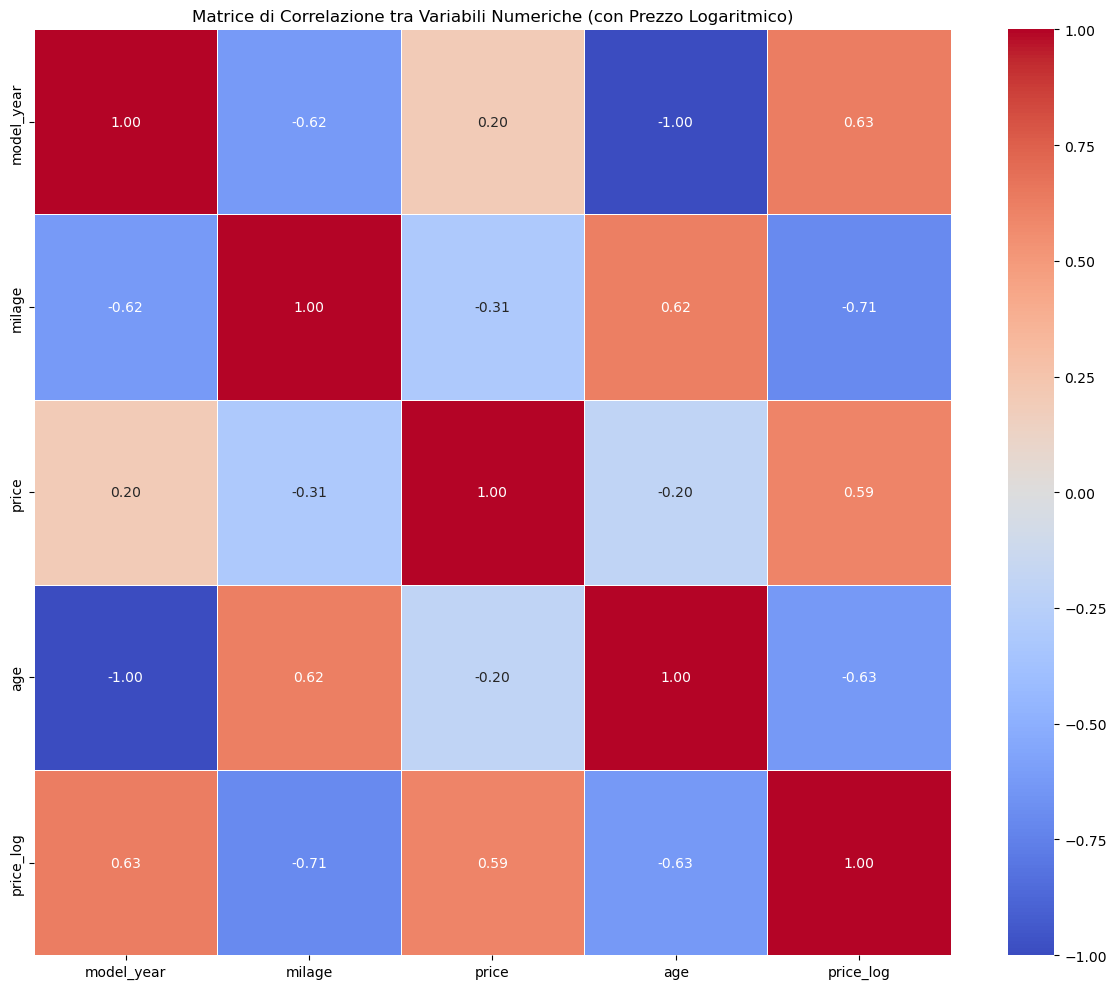

In [311]:

numeric_df = df.select_dtypes(include=[np.number])
correlation_log = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_log, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice di Correlazione tra Variabili Numeriche (con Prezzo Logaritmico)')
plt.tight_layout()
plt.show()


Correlazioni perfette (1.00 o -1.00):

* model_year e age sono perfettamente correlati negativamente (-1.00): ovvio, perché l'età è derivata dall'anno del modello (age = anno_corrente - model_year)
* model_year ha una correlazione positiva perfetta con se stesso (1.00), come tutte le variabili sulla diagonale


### Correlazioni significative:

* price_log e model_year: correlazione positiva (0.63) - auto più recenti hanno prezzi più alti
* price_log e milage: correlazione negativa (-0.71) - più chilometri, prezzo più basso
* price_log e price: correlazione positiva (0.59) - prezzo reale e logaritmico sono correlati (ovvio)
* milage e model_year: correlazione negativa (-0.62) - auto più vecchie tendono ad avere più chilometri
* milage e age: correlazione positiva (0.62) - auto più anziane hanno più chilometri


### Correlazioni deboli:

* price e model_year: correlazione positiva debole (0.20)
* price e milage: correlazione negativa debole (-0.31)
* price e age: correlazione negativa debole (-0.20)



Questa matrice di correlazione conferma alcune relazioni intuitive (come l'effetto negativo del chilometraggio sul prezzo) e mostra che **la trasformazione logaritmica del prezzo (price_log) ha correlazioni più forti con le altre variabili rispetto al prezzo originale**, suggerendo che il logaritmo del prezzo potrebbe essere una variabile più utile per l'analisi e la modellazione.

## Identifica i primi 10 brand (per numero di macchine)

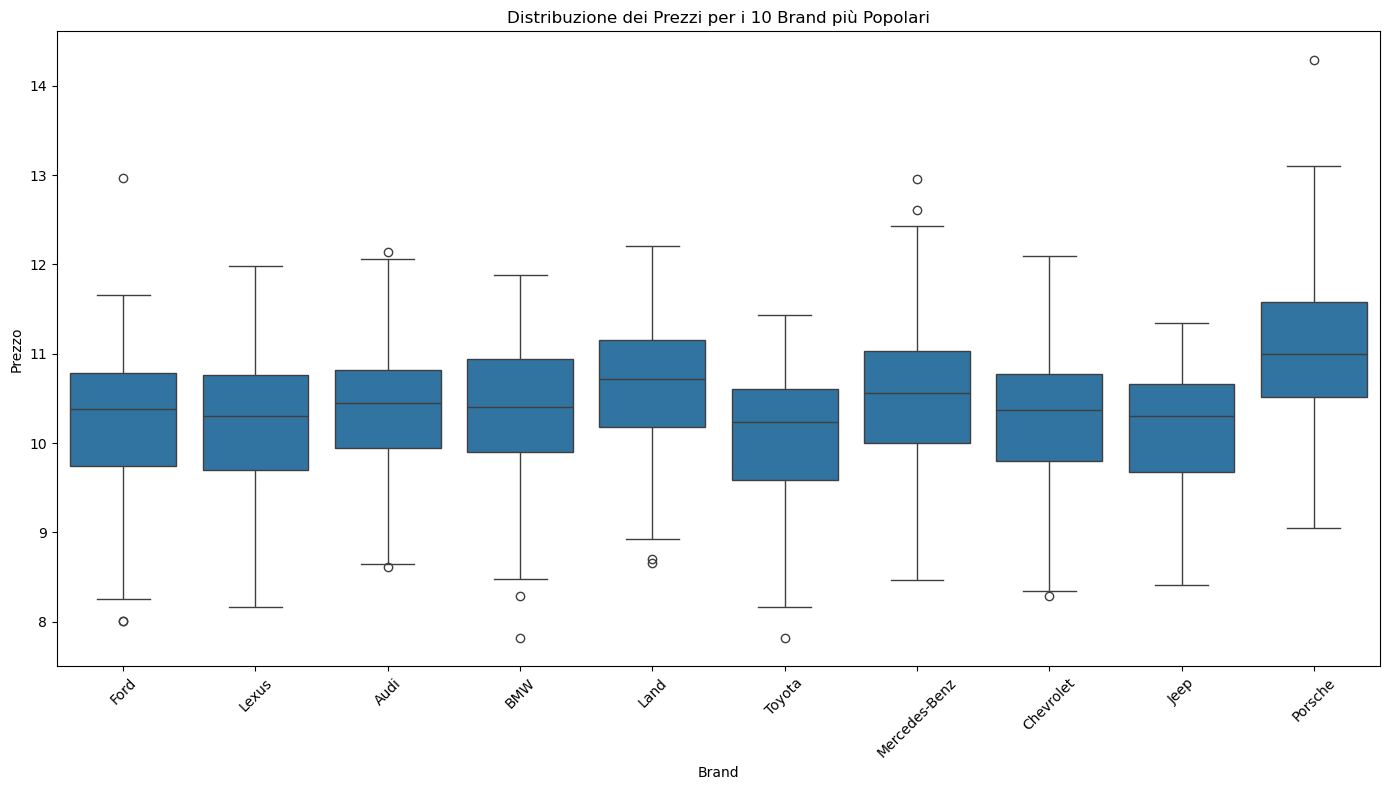

In [312]:
top_10_brands = df['brand'].value_counts().nlargest(10).index.tolist()

# Filtra il dataframe per includere solo questi brand
df_top10 = df[df['brand'].isin(top_10_brands)]

# Crea il box plot con i dati filtrati
plt.figure(figsize=(14, 8))
sns.boxplot(x='brand', y='price_log', data=df_top10)
plt.title('Distribuzione dei Prezzi per i 10 Brand più Popolari')
plt.xlabel('Brand')
plt.ylabel('Prezzo')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

Osservazioni chiave:

* Porsche ha il prezzo mediano più alto tra i 10 brand popolari
* Toyota ha i prezzi mediamente più bassi nel gruppo
* Alcuni brand come Ford e BMW mostrano outlier verso l'alto
* La maggior parte dei brand ha la mediana dei prezzi attorno al valore 10 nella scala logaritmica


## Controllo se emergono pattern più chiari con la trasformazione logaritmica

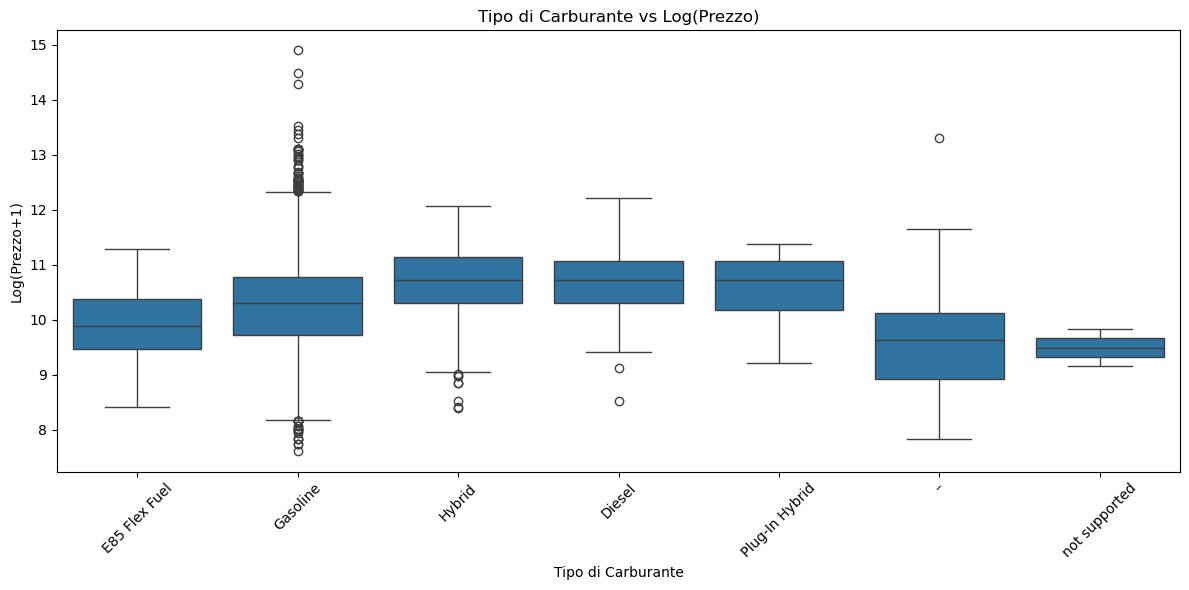

In [313]:

if 'fuel_type' in df.columns and df['fuel_type'].notna().any():
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='fuel_type', y='price_log', data=df)
    plt.title('Tipo di Carburante vs Log(Prezzo)')
    plt.xlabel('Tipo di Carburante')
    plt.ylabel('Log(Prezzo+1)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


I tipi di carburante includono: E85 Flex Fuel, Gasoline (Benzina), Hybrid (Ibrido), Diesel, Plug-in Hybrid, e una categoria "not reported" (non segnalato)
* Le auto ibride e diesel tendono ad avere i prezzi mediani più alti
* Le auto a benzina hanno la maggiore variabilità di prezzo, con outlier sia molto alti che molto bassi
* Le auto con carburante non segnalato hanno i prezzi più bassi e con minore variabilità
* I veicoli Plug-in Hybrid hanno prezzi generalmente più alti rispetto alle auto a benzina tradizionali

## Gli outlier e Gasoline
gli outlier sembrano concentrati nel tipo di carburante "Gasoline".
potrebbero esserci caratteristiche specifiche di alcuni veicoli a benzina (probabilmente auto sportive o di lusso) che seguono un modello di prezzo diverso?

### Relazione tra chilometraggio e prezzo logaritmico con linea di tendenza

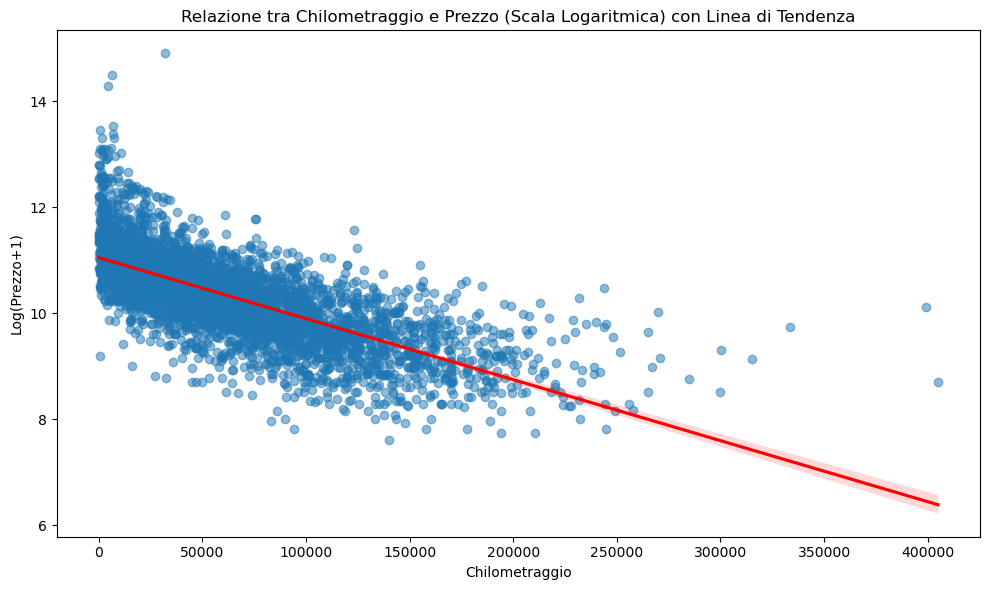

In [316]:

plt.figure(figsize=(10, 6))
sns.regplot(x='milage', y='price_log', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relazione tra Chilometraggio e Prezzo (Scala Logaritmica) con Linea di Tendenza')
plt.xlabel('Chilometraggio')
plt.ylabel('Log(Prezzo+1)')
plt.tight_layout()
plt.show()

mostra la relazione tra chilometraggio e prezzo (in scala logaritmica) delle auto, con una linea di tendenza rossa.

* L'asse X rappresenta il chilometraggio (da 0 a 400.000 km)
* L'asse Y rappresenta il prezzo in scala logaritmica
* La linea di tendenza rossa mostra chiaramente una correlazione negativa: all'aumentare del chilometraggio, il prezzo tende a diminuire
* La pendenza della linea è più ripida inizialmente e diventa più graduale con l'aumentare del chilometraggio
* La nuvola di punti è più densa nella zona con chilometraggio basso (0-100.000 km)

## Controllo se ci sono outlier nella scala logaritmica, e come sarebbe il dataset senza di essi

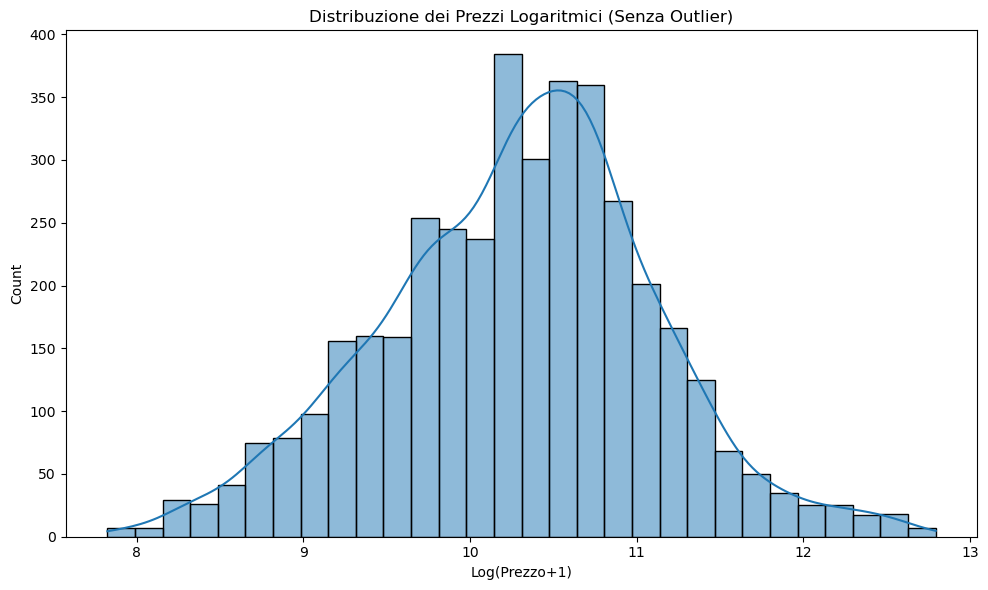


Correlazioni con prezzo logaritmico (senza outlier):
price_log     1.000000
price         0.834357
model_year    0.646235
age          -0.646235
milage       -0.713035
Name: price_log, dtype: float64


In [317]:

if outliers_log.sum() > 0:
    df_no_log_outliers = df[~outliers_log]
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df_no_log_outliers['price_log'], bins=30, kde=True)
    plt.title('Distribuzione dei Prezzi Logaritmici (Senza Outlier)')
    plt.xlabel('Log(Prezzo+1)')
    plt.tight_layout()
    plt.show()
    
    # Verifica correlazioni senza outlier
    corr_no_outliers = df_no_log_outliers.select_dtypes(include=[np.number]).corr()['price_log'].sort_values(ascending=False)
    print("\nCorrelazioni con prezzo logaritmico (senza outlier):")
    print(corr_no_outliers)

# Inizio lavoro post EDA

## Credo sia il caso di portare avanti  una versione con "outlier" e metterli in una categoria specifica
Creerò una nuova feature che accorpi nuove feature, (es, brand di lusso, sportiva etc)

In [318]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Divisione in X e y (manteniamo tutti i dati, inclusi gli outlier)


In [319]:
X = df.drop(['price', 'price_log'], axis=1)  # Rimuoviamo sia price che price_log da X
y = df['price_log']  # Usiamo il prezzo logaritmico come target

In [320]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [321]:
X_train.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,age,ext_color_brightness
2473,Ford,Explorer Platinum,2018,73049,Gasoline,3.5L V6 24V GDI DOHC Twin Turbo,6-Speed Automatic,Gray,Ebony Black,At least 1 accident or damage reported,Yes,7,Medium
1338,GMC,Yukon XL AT4,2023,9980,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,Black,Black,None reported,Yes,2,Dark
1613,BMW,M3 Base,2016,55250,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,Blue,White,None reported,Yes,9,Medium
1610,Lexus,IS 350 Base,2017,77300,Gasoline,306.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,None reported,Yes,8,Light
2600,Ford,Focus SE,2018,33700,E85 Flex Fuel,160.0HP 2.0L 4 Cylinder Engine Flex Fuel Capab...,A/T,Gray,Black,At least 1 accident or damage reported,Yes,7,Medium


### Identificazione delle colonne per tipo (num, cat)

In [322]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print(f"Colonne numeriche: {numeric_cols}")
print(f"Colonne categoriche: {categorical_cols}")

Colonne numeriche: ['model_year', 'milage', 'age']
Colonne categoriche: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'ext_color_brightness']


## Feature Engineering Transformer personalizzato
Creo una classe che usa `BaseEstimator` e `TransformerMixin` di scikit-learn per creare nuove caratteristiche dai dati del dataframe.


La classe arricchisce il dataset originale con **sei nuove feature**: 
* un indicatore di auto di lusso basato sul brand (is_luxury), 
* il rapporto tra età e chilometraggio (milage_per_year), 
* un punteggio delle condizioni dell'auto basato sugli incidenti (condition_score), 
* un indicatore di auto sportiva basato sul modello (is_sport), 
* una combinazione di lusso e sportività (luxury_sport), 
* e una stima della potenza del motore estratta dalla descrizione del motore (engine_power).

In seguito ho aggiunto la **follia dei colori**, che posso conotrollare nella classe con `use_color_feature='True/False'`:

* is_premium_ext_color: Flag per colori esterni costosi (Tempest, China Blue, etc.)
* is_premium_int_color: Flag per interni di alta gamma (Charles Blue, Brandy, etc.)
* common_color_combo: Flag per combinazioni colore frequenti (Black-Black, White-Beige)
* ext_color_brightness: Categoria di luminosità (Light, Dark, Medium, Other)
* is_specialty_color: Flag per colori speciali/non standard
* brightness_*: Variabili dummy per ciascuna categoria di luminosità
* brand_specific_premium_color: Flag per colori iconici di specifiche marche (BMW-Silver, Porsche-Green)
* high_variance_color: Flag per colori presenti su auto di fasce di prezzo diverse
* is_metallic_color: Flag per finiture speciali (metallizzato, perlato, satinato)

Il codice **include logica per gestire valori mancanti e trasforma i dati categorici in features numeriche utilizzabili per l'analisi predittiva**. Questa classe è progettata per **essere utilizzata all'interno di una pipeline scikit-learn per automatizzare il preprocessing dei dati prima dell'addestramento di modelli di machine learning**.

In [323]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, luxury_brands=None, sport_models=None, use_color_features=True):
        self.luxury_brands = luxury_brands or ['Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Tesla', 'Land Rover', 'Jaguar', 'Maserati', 'Bentley', 'Aston']
        self.sport_models = sport_models or ['Sport', 'RS', 'M', 'AMG', 'GTR', 'GT', 'R', 'S', 'Roadster', 'Spyder', 'Coupe']
        # Parametro per attivare/disattivare le feature dei colori
        self.use_color_features = use_color_features
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        # ==================== FEATURE ORIGINALI ====================
        
        # Sostituisce NaN nelle colonne accident con 'None reported'
        if 'accident' in X_copy.columns:
            X_copy['accident'] = X_copy['accident'].fillna('None reported')
        
        # Feature 1: Indicatore di auto di lusso basato sul brand
        if 'brand' in X_copy.columns:
            X_copy['is_luxury'] = X_copy['brand'].apply(lambda x: 1 if any(luxury in str(x) for luxury in self.luxury_brands) else 0)
        
        # Feature 2: Rapporto tra età e chilometraggio (milage per anno)
        if 'model_year' in X_copy.columns and 'milage' in X_copy.columns:
            current_year = 2024
            X_copy['age'] = current_year - X_copy['model_year']
            X_copy['milage_per_year'] = X_copy['milage'] / (X_copy['age'] + 1)  # +1 per evitare divisione per zero
        
        # Feature 3: Condizioni dell'auto basate sul numero di incidenti
        if 'accident' in X_copy.columns:
            condition_map = {
                'None reported': 2,        # Ottimo
                'At least 1 accident or damage reported': 1,  # Buono
                np.nan: 1.5                # Sconosciuto (valore medio)
            }
            X_copy['condition_score'] = X_copy['accident'].map(condition_map)
        
        # Feature 4: Auto sportiva basata sul modello
        if 'model' in X_copy.columns:
            X_copy['is_sport'] = X_copy['model'].apply(lambda x: 1 if any(sport in str(x) for sport in self.sport_models) else 0)
        
        # Feature 5: Combinazione di lusso e sportiva
        if 'is_luxury' in X_copy.columns and 'is_sport' in X_copy.columns:
            X_copy['luxury_sport'] = X_copy['is_luxury'] * X_copy['is_sport']
        
        # Feature 6: Potenza motore stimata (dalla descrizione del motore, se disponibile)
        if 'engine' in X_copy.columns:
            def extract_hp(engine_desc):
                if pd.isna(engine_desc):
                    return np.nan
                engine_desc = str(engine_desc)
                if 'HP' in engine_desc or 'hp' in engine_desc:
                    try:
                        # Estrarre il numero prima di "HP" o "hp"
                        hp_str = ''.join(c for c in engine_desc.split('HP')[0].split('hp')[0] if c.isdigit() or c == '.')
                        return float(hp_str) if hp_str else np.nan
                    except:
                        return np.nan
                return np.nan
            
            X_copy['engine_power'] = X_copy['engine'].apply(extract_hp)
        
        # ==================== FEATURE SUI COLORI ====================
        # Procedi solo se use_color_features è True
        if self.use_color_features:
            # Colori esterni premium (i più costosi secondo le immagini)
            premium_ext_colors = ['Tempest', 'Balloon White', 'China Blue', 'Bianco Ira',
                                'BLU ELEOS', 'Bianco Monocromo', 'Red']
        
            # Colori interni premium (i più costosi secondo le immagini)
            premium_int_colors = ['Charles Blue', 'Cobalt Blue', 'Black / Brown', 'Brandy', 'Grace White']
        
            # Feature per colori premium
            if 'ext_col' in X_copy.columns:
                X_copy['is_premium_ext_color'] = X_copy['ext_col'].apply(
                    lambda x: 1 if x is not None and (x in premium_ext_colors or 
                                any(color in str(x) for color in premium_ext_colors)) else 0)
        
            if 'int_col' in X_copy.columns:
                X_copy['is_premium_int_color'] = X_copy['int_col'].apply(
                    lambda x: 1 if x is not None and (x in premium_int_colors or 
                                any(color in str(x) for color in premium_int_colors)) else 0)
        
            # Combinazioni colore più presenti nella heatmap (Black-Black, White-Beige, ecc.)
            if 'ext_col' in X_copy.columns and 'int_col' in X_copy.columns:
                # Combinazioni più frequenti dalla heatmap
                premium_combinations = [
                    ('Black', 'Black'), ('Black', 'Beige'), ('Gray', 'Black'), 
                    ('White', 'Beige'), ('Gray', 'Gray')
                ]
            
                # Verifica se la combinazione esiste (considerando anche substring)
                X_copy['common_color_combo'] = X_copy.apply(
                    lambda row: 1 if None not in [row['ext_col'], row['int_col']] and 
                                    any((ext in str(row['ext_col']) and int_c in str(row['int_col'])) 
                                    for ext, int_c in premium_combinations) else 0,
                    axis=1
                )
        
            # Luminosità del colore (la categoria "Other" sembra avere prezzi più alti)
            if 'ext_col' in X_copy.columns:
                X_copy['ext_color_brightness'] = X_copy['ext_col'].apply(self.categorize_color_brightness)
            
                # Aggiungi un flag per la categoria "Other" che sembra avere prezzi più alti
                X_copy['is_specialty_color'] = (X_copy['ext_color_brightness'] == 'Other').astype(int)
            
                # Converti categorie di luminosità in variabili dummy
                brightness_dummies = pd.get_dummies(X_copy['ext_color_brightness'], 
                                            prefix='brightness')
                X_copy = pd.concat([X_copy, brightness_dummies], axis=1)
        
            # Colori specifici per marche di lusso
            if 'brand' in X_copy.columns and 'ext_col' in X_copy.columns:
                # Colori costosi per marche specifiche
                premium_brand_colors = {
                    'Ford': ['Dark Gray Metallic', 'Dark Matter Metallic', 'Oxford White'],
                    'BMW': ['Frozen Dark Silver Metallic', 'Aventurin Metallic', 'Dravit Grey Metallic'],
                    'Mercedes-Benz': ['China Blue', 'Diamond White', 'Designo Magno Matte'],
                    'Porsche': ['Python Green', 'GT Silver'],
                    'Chevrolet': ['Arctic White', 'Silver Flare Metallic']
                }
            
                def is_premium_brand_color(brand, color):
                    if brand in premium_brand_colors and color is not None:
                        brand_premium_colors = premium_brand_colors[brand]
                        return 1 if any(premium in str(color) for premium in brand_premium_colors) else 0
                    return 0
            
                X_copy['brand_specific_premium_color'] = X_copy.apply(
                    lambda row: is_premium_brand_color(row['brand'], row['ext_col']), 
                    axis=1
                )
        
            # Varianza del prezzo per colore
            if 'ext_col' in X_copy.columns:
                # Colori con alta varianza di prezzo (potrebbero essere colori presenti su modelli vari)
                high_variance_colors = ['Red', 'Yellow', 'White', 'Gray', 'Purple']
            
                X_copy['high_variance_color'] = X_copy['ext_col'].apply(
                    lambda x: 1 if x is not None and any(color.lower() in str(x).lower() 
                                    for color in high_variance_colors) else 0
                )
        
            # Colori metallizzati/perlati (generalmente più costosi)
            if 'ext_col' in X_copy.columns:
                metallic_terms = ['metallic', 'pearl', 'pearlescent', 'matte', 'satin', 'gloss', 'chrome']
            
                X_copy['is_metallic_color'] = X_copy['ext_col'].apply(
                    lambda x: 1 if x is not None and any(term in str(x).lower() 
                                                for term in metallic_terms) else 0
                )
        
        return X_copy

    # Funzione per categorizzare la luminosità del colore
    def categorize_color_brightness(self, color):
        if color is None:
            return 'Unknown'
    
        color = str(color).lower()
    
        # Colori chiari
        light_colors = ['white', 'silver', 'beige', 'cream', 'ivory', 'gold', 'yellow', 'light']
    
        # Colori scuri
        dark_colors = ['black', 'charcoal', 'midnight', 'navy', 'dark', 'ebony']
    
        # Colori medi
        medium_colors = ['red', 'blue', 'green', 'orange', 'purple', 'gray', 'grey', 'brown']
    
        # Controlla a quale categoria appartiene
        if any(light in color for light in light_colors):
            return 'Light'
        elif any(dark in color for dark in dark_colors):
            return 'Dark'
        elif any(medium in color for medium in medium_colors):
            return 'Medium'
        else:
            return 'Other'  # Colori speciali o non classificabili

## Preprocessori per i diversi tipi di colonne
Creo i transformer numerici e categorici.

Per i numerici uso la mediana per renderlo più robusto agli outlier.

Per le categoriche uso la moda.

In [324]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

### Pipeline base (senza feature engineering)
Creo i preprocessori usando `ColumnTransformer` che usano i due transformer sopra

In [325]:
preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

### Preparazione dei dati che avranno il feature engineering
Devo identificare le nuove colonne.
Creo `X_train_fe` che trasformerà `X_train` usando la classe che abbiamo definito prima.

E visto che rispetto all'originale cambiano i nomi delle colonne li rigenero

In [326]:
feature_eng = FeatureEngineer()
X_train_fe = feature_eng.transform(X_train)
new_numeric_cols = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
new_categorical_cols = X_train_fe.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print(f"\nColonne numeriche dopo feature engineering: {new_numeric_cols}")
print(f"Colonne categoriche dopo feature engineering: {new_categorical_cols}")


Colonne numeriche dopo feature engineering: ['model_year', 'milage', 'age', 'is_luxury', 'milage_per_year', 'condition_score', 'is_sport', 'luxury_sport', 'engine_power', 'is_premium_ext_color', 'is_premium_int_color', 'common_color_combo', 'is_specialty_color', 'brand_specific_premium_color', 'high_variance_color', 'is_metallic_color']
Colonne categoriche dopo feature engineering: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'ext_color_brightness', 'brightness_Dark', 'brightness_Light', 'brightness_Medium', 'brightness_Other']


### Pipeline (con feature engineering)
Creo i preprocessori usando `ColumnTransformer` che usano i due transformer sopra, questa volta con i dati lavorati

In [327]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, new_numeric_cols),
        ('cat', categorical_transformer, new_categorical_cols)
    ])

### Imposto i modelli da testare
Creo un oggetto che contiene coppie di valori composte:
* Nome modello - Istanza modello
In questo modo posso iterare nell'oggetto dopo.

In [328]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

### Creo una funzione che possa valutare i modelli.

* Creazione della pipeline completa: Combina il preprocessore e il modello in un'unica pipeline
* Addestramento: Esegue il fit della pipeline sui dati di training
* Predizione: Genera previsioni sui dati di test

#### Metriche di valutazione:

* RMSE (Root Mean Square Error): Misura l'errore quadratico medio in scala logaritmica
* MAE (Mean Absolute Error): Misura l'errore assoluto medio in scala logaritmica
* R²: Coefficiente di determinazione che indica la proporzione di varianza spiegata dal modello
* MAPE (Mean Absolute Percentage Error): Percentuale media di errore calcolata sui prezzi riconvertiti alla scala originale


#### Conversione dei prezzi:

Trasforma sia i valori reali (`y_test`) che quelli predetti (`y_pred`) **dalla scala logaritmica alla scala originale** usando `np.expm1()`
Questo è fondamentale per calcolare il MAPE, che fornisce un'interpretazione più intuitiva dell'errore in termini percentuali

#### Output:

Restituisce:
* **la pipeline addestrata e un dizionario con le metriche di performance**


In [329]:
def evaluate_model(model_name, model, pipeline, X_train, X_test, y_train, y_test):
    print(f"Valutazione di {model_name}...")
    
    # Creiamo la pipeline completa
    full_pipeline = Pipeline(steps=[
        ('pipeline', pipeline),
        ('model', model)
    ])
    
    # Addestramento
    full_pipeline.fit(X_train, y_train)
    
    # Predizione
    y_pred = full_pipeline.predict(X_test)
    
    # Metriche (sul prezzo logaritmico)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Conversione in prezzi originali per interpretabilità
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    
    # Errore percentuale medio
    mape = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
    
    return full_pipeline, {
        'RMSE (log)': rmse,
        'MAE (log)': mae,
        'R2': r2,
        'MAPE (%)': mape
    }

### Eseguo la funzione per valutare i modelli, iterando nell'oggetto model.
Per ogni modello viene fatta sia la versione con feature base che con i nuovi dati.

I `for` loop addestrano ogni modello

**Prima di addestrare i modelli con feature engineering, dobbiamo trasformare i dati per includere le nuove feature.**

Poi butto fuori i risultati con un print, sia per i modelli con feature base che quelli con feature lavorate

In [330]:
results_base = {}
trained_models_base = {}
results_fe = {}
trained_models_fe = {}

# Pipeline per modelli base
for name, model in models.items():
    pipeline_base, metrics = evaluate_model(name, model, preprocessor_base, X_train, X_test, y_train, y_test)
    results_base[name] = metrics
    trained_models_base[name] = pipeline_base

# Pipeline per modelli con feature engineering
# Prima applichiamo feature engineering
X_train_fe = feature_eng.transform(X_train)
X_test_fe = feature_eng.transform(X_test)

for name, model in models.items():
    pipeline_fe, metrics = evaluate_model(name, model, preprocessor_fe, X_train_fe, X_test_fe, y_train, y_test)
    results_fe[name] = metrics
    trained_models_fe[name] = pipeline_fe

# 12. Visualizzazione dei risultati in formato tabella
results_df_base = pd.DataFrame(results_base).T
results_df_fe = pd.DataFrame(results_fe).T

print("\nRisultati con feature base:")
print(results_df_base)

print("\nRisultati con feature engineering:")
print(results_df_fe)

Valutazione di LinearRegression...
Valutazione di Ridge...
Valutazione di Lasso...
Valutazione di RandomForest...
Valutazione di GradientBoosting...
Valutazione di LinearRegression...
Valutazione di Ridge...
Valutazione di Lasso...
Valutazione di RandomForest...
Valutazione di GradientBoosting...

Risultati con feature base:
                  RMSE (log)  MAE (log)        R2   MAPE (%)
LinearRegression    0.447434   0.250029  0.742902  25.300669
Ridge               0.410117   0.226272  0.783999  22.767962
Lasso               0.616580   0.446721  0.511777  47.252340
RandomForest        0.456467   0.312042  0.732416  32.367016
GradientBoosting    0.477197   0.336741  0.707561  35.671111

Risultati con feature engineering:
                  RMSE (log)  MAE (log)        R2   MAPE (%)
LinearRegression    0.441217   0.246582  0.749998  24.863871
Ridge               0.408580   0.224725  0.785615  22.545182
Lasso               0.605806   0.436093  0.528690  45.855882
RandomForest        0.38524

In [334]:
X_train.head(2)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,age,ext_color_brightness
2473,Ford,Explorer Platinum,2018,73049,Gasoline,3.5L V6 24V GDI DOHC Twin Turbo,6-Speed Automatic,Gray,Ebony Black,At least 1 accident or damage reported,Yes,7,Medium
1338,GMC,Yukon XL AT4,2023,9980,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,Black,Black,None reported,Yes,2,Dark


In [335]:
X_train_fe.head(2)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,...,is_premium_int_color,common_color_combo,is_specialty_color,brightness_Dark,brightness_Light,brightness_Medium,brightness_Other,brand_specific_premium_color,high_variance_color,is_metallic_color
2473,Ford,Explorer Platinum,2018,73049,Gasoline,3.5L V6 24V GDI DOHC Twin Turbo,6-Speed Automatic,Gray,Ebony Black,At least 1 accident or damage reported,...,0,1,0,False,False,True,False,0,1,0
1338,GMC,Yukon XL AT4,2023,9980,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,Black,Black,None reported,...,0,1,0,True,False,False,False,0,0,0


## Creo un grafico 📊 per mostrare i risultati ottenuti sopra 👆

Per ogni metrica:
* $R^2$
* MAPE
* RMSE
* MAE

Creo un plot dove mostro i modelli usati, mettendo a confronto le variazioni per singola metrica per feature base o feuture avanzate

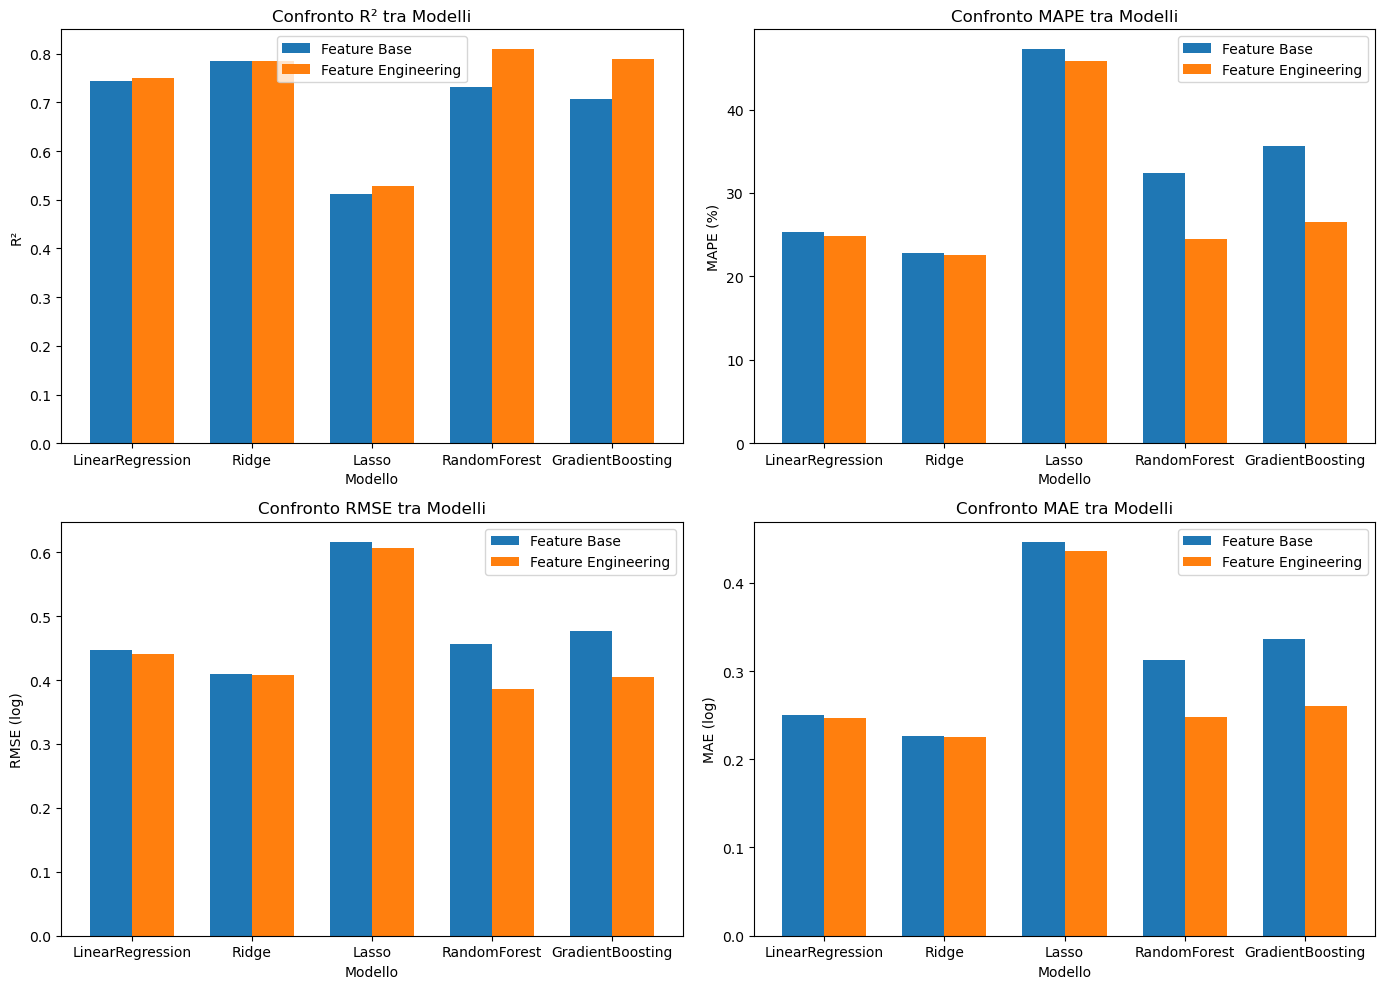

In [336]:
plt.figure(figsize=(14, 10))

# R² comparison
plt.subplot(2, 2, 1)
bar_width = 0.35
indices = np.arange(len(models))
plt.bar(indices - bar_width/2, results_df_base['R2'], bar_width, label='Feature Base')
plt.bar(indices + bar_width/2, results_df_fe['R2'], bar_width, label='Feature Engineering')
plt.xlabel('Modello')
plt.ylabel('R²')
plt.title('Confronto R² tra Modelli')
plt.xticks(indices, results_df_base.index)
plt.legend()

# MAPE comparison
plt.subplot(2, 2, 2)
plt.bar(indices - bar_width/2, results_df_base['MAPE (%)'], bar_width, label='Feature Base')
plt.bar(indices + bar_width/2, results_df_fe['MAPE (%)'], bar_width, label='Feature Engineering')
plt.xlabel('Modello')
plt.ylabel('MAPE (%)')
plt.title('Confronto MAPE tra Modelli')
plt.xticks(indices, results_df_base.index)
plt.legend()

# RMSE comparison
plt.subplot(2, 2, 3)
plt.bar(indices - bar_width/2, results_df_base['RMSE (log)'], bar_width, label='Feature Base')
plt.bar(indices + bar_width/2, results_df_fe['RMSE (log)'], bar_width, label='Feature Engineering')
plt.xlabel('Modello')
plt.ylabel('RMSE (log)')
plt.title('Confronto RMSE tra Modelli')
plt.xticks(indices, results_df_base.index)
plt.legend()

# MAE comparison
plt.subplot(2, 2, 4)
plt.bar(indices - bar_width/2, results_df_base['MAE (log)'], bar_width, label='Feature Base')
plt.bar(indices + bar_width/2, results_df_fe['MAE (log)'], bar_width, label='Feature Engineering')
plt.xlabel('Modello')
plt.ylabel('MAE (log)')
plt.title('Confronto MAE tra Modelli')
plt.xticks(indices, results_df_base.index)
plt.legend()

plt.tight_layout()
plt.show()

* **R² (Coefficiente di determinazione)**:
Misura la proporzione della varianza nella variabile dipendente (prezzo) che è prevedibile dalle variabili indipendenti. Varia da 0 a 1, dove 1 indica che il modello spiega perfettamente la variabilità dei dati. Più alto è il valore, migliore è il modello.
* **MAPE (Mean Absolute Percentage Error)**:
Esprime l'errore medio come percentuale del valore reale. Ad esempio, un MAPE del 20% significa che, in media, le previsioni sono errate del 20% rispetto ai valori reali. Più basso è il valore, migliore è il modello.
* **RMSE (Root Mean Square Error)**:
La radice quadrata della media degli errori al quadrato. Penalizza gli errori grandi più degli errori piccoli. È espresso nella stessa unità della variabile target (es. dollari per i prezzi). Più basso è il valore, migliore è il modello.
* **MAE (Mean Absolute Error)**:
Media degli errori assoluti tra valori previsti e valori reali. È meno sensibile agli outlier rispetto all'RMSE. Come l'RMSE, è espresso nella stessa unità della variabile target. Più basso è il valore, migliore è il modello.

## Voglio identificare i modelli migliori per feature base e feature avanzate 🏆

In [338]:
best_model_base = results_df_base['R2'].idxmax()
best_r2_base = results_df_base.loc[best_model_base, 'R2']
best_model_fe = results_df_fe['R2'].idxmax()
best_r2_fe = results_df_fe.loc[best_model_fe, 'R2']

print(f"\nMiglior modello con feature base: {best_model_base} (R² = {best_r2_base:.4f})")
print(f"Miglior modello con feature engineering: {best_model_fe} (R² = {best_r2_fe:.4f})")
print(f"Miglioramento con feature engineering: {((best_r2_fe - best_r2_base) / best_r2_base) * 100:.2f}%")


Miglior modello con feature base: Ridge (R² = 0.7840)
Miglior modello con feature engineering: RandomForest (R² = 0.8094)
Miglioramento con feature engineering: 3.24%


### Cerco di capire quali feature hanno avuto più 'importanza' con feature engineering

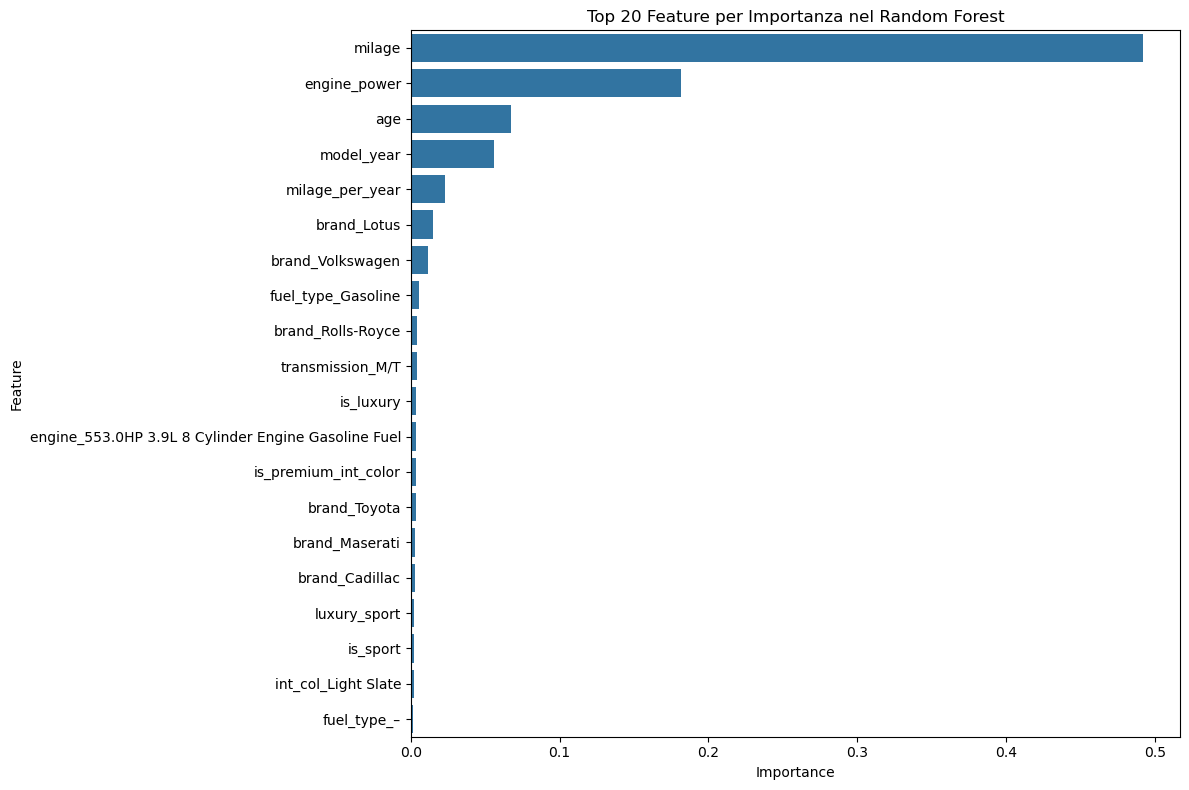


Top 20 Feature per Importanza nel Random Forest:
                                                Feature  Importance
1                                                milage    0.492352
8                                          engine_power    0.181625
2                                                   age    0.067121
0                                            model_year    0.055880
4                                       milage_per_year    0.022713
58                                          brand_Lotus    0.014746
40                                     brand_Volkswagen    0.011726
1706                                 fuel_type_Gasoline    0.005324
61                                    brand_Rolls-Royce    0.003960
2776                                   transmission_M/T    0.003849
3                                             is_luxury    0.003700
2455  engine_553.0HP 3.9L 8 Cylinder Engine Gasoline...    0.003681
10                                 is_premium_int_color    0.00360

In [339]:
if 'RandomForest' in models:
    # Otteniamo il modello addestrato
    rf_model_fe = trained_models_fe['RandomForest'].named_steps['model']
    
    # Estraiamo le feature dopo il preprocessamento
    # potrebbe generare nomi di feature diversi
    feature_names = new_numeric_cols.copy()
    
    # Aggiungiamo le feature categoriche dopo one-hot encoding
    for cat in new_categorical_cols:
        # Approssimiamo i nomi delle feature one-hot
        if cat in X_train_fe:
            unique_values = X_train_fe[cat].dropna().unique()
            for val in unique_values:
                feature_names.append(f"{cat}_{val}")
    
    # Otteniamo l'importanza delle feature
    importances = rf_model_fe.feature_importances_
    
    # Creiamo un DataFrame per la visualizzazione
    # Nota: questo è un approccio approssimativo poiché non abbiamo accesso esatto
    # ai nomi delle feature dopo il preprocessamento
    n_features = min(len(importances), len(feature_names))
    feature_importance = pd.DataFrame({
        'Feature': feature_names[:n_features],
        'Importance': importances[:n_features]
    }).sort_values('Importance', ascending=False)
    
    # Visualizziamo le top 20 feature
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
    plt.title('Top 20 Feature per Importanza nel Random Forest')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 20 Feature per Importanza nel Random Forest:")
    print(feature_importance.head(20))